# BATCH

## Setup
Import

In [ ]:
# ============================================================
# IMPORT
# ============================================================

# --- Libreria standard ---
import os
from itertools import cycle

# --- Manipolazione dati e numerica ---
import numpy as np
import pandas as pd

# --- Immagini ---
from PIL import Image
import cv2
from skimage import color  # conversione LAB per stain normalization e istogrammi

# --- Visualizzazione ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Download dataset ---
import kagglehub

# --- Scikit-learn: split, bilanciamento classi, metriche ---
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2, MobileNetV2
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input_fn
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess_input_fn
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess_input_fn

# --- Altro ---
import time

Configurazione

In [ ]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

IMG_SIZE = 224 #ridotto da 256 perché è lo standard per cui ResNet50V2/EfficientNetB0/MobileNetV2 sono stati pre-addestrati su ImageNet
BATCH_SIZE = 40
NUM_CLASSES = 3
SEED = 42
FINE_TUNE_FRACTION = 0.20

label_to_index = {"Normal": 0, "Benign": 1, "Malign": 2}
index_to_label = {v: k for k, v in label_to_index.items()}

Downlaod dataset

In [ ]:
# ============================================================
# DOWNLOAD DATASET
# ============================================================

# Download dell'intero dataset (kagglehub lo mette in cache, quindi
# le esecuzioni successive non lo riscaricano)
path = kagglehub.dataset_download(
    "truthisneverlinear/bach-breast-cancer-histology-images"
)

print("Path al dataset:", path)

FOLDER_PATH = os.path.join(path, "ICIAR2018_BACH_Challenge", "ICIAR2018_BACH_Challenge", "Photos")
img_path = os.path.join(FOLDER_PATH, "InSitu", "is002.tif")

100%|██████████| 12.5G/12.5G [10:58<00:00, 20.4MB/s]

Extracting files...


Path al dataset: /root/.cache/kagglehub/datasets/truthisneverlinear/bach-breast-cancer-histology-images/versions/1




---



## Esplorazione dati


Caricamento e visualizzazione di un'immagine di esempio

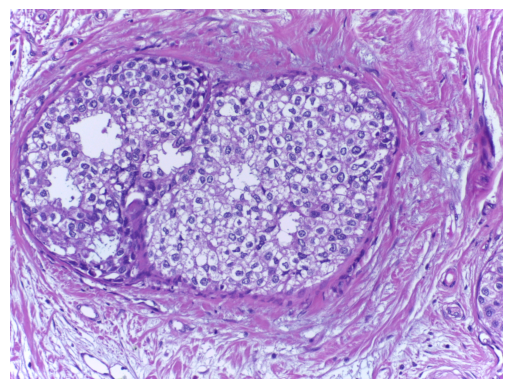

In [ ]:
img = Image.open(img_path)  # apre il file immagine specificato dal percorso

plt.imshow(img)   # visualizza l'immagine caricata
plt.axis("off")   # disattiva la visualizzazione degli assi
plt.show()        # mostra la figura

Costruzione del DataFrame

In [ ]:
def create_dataset(data=None, folder_path=None):   # definisco una funzione che organizza i percorsi e le relative etichette
    if data is None:
        data = []   # evita il problema del valore di default mutabile condiviso tra chiamate

    valid_ext = (".png", ".jpg", ".jpeg", ".tif", ".tiff")  # definisce le estensioni valide

    for label in os.listdir(folder_path):                 # elenca tutti gli elementi (sottocartelle) all'interno del folder_path
        label_path = os.path.join(folder_path, label)     # costruisce il percorso completo per la sottocartella
        if not os.path.isdir(label_path):       # controlla se l'elemento corrente è effettivamente una directory
            continue

        # Nuova etichetta: rieticheetta per unire le categorie
        if label in ["InSitu", "Invasive"]:
            new_label = "Malign"
        else: new_label = label

        for file_name in os.listdir(label_path):              # all'interno di ogni cartella di etichetta, la funzione elenca tutti i file presenti
            file_path = os.path.join(label_path, file_name)   # costruisce il percorso completo per il file corrente

            if not os.path.isfile(file_path):   # controlla se l'elemento corrente è effettivamente un file
                continue

            if not file_name.lower().endswith(valid_ext): #e se ha una delle estensioni permesse
                continue

            # Se il file è un'immagine valida, un dizionario contenente il suo percorso
            # completo (file_path) e la sua new_label (potenzialmente ri-etichettata) viene
            # aggiunto alla lista data

            data.append({
                "file_path": file_path,
                "label": new_label
            })

    return data


df = pd.DataFrame(create_dataset(folder_path=FOLDER_PATH))    # creare un nuovo DataFrame Pandas

df.head()   # stampa le prime 5 righe

,file_path,label
0,/root/.cache/kagglehub/datasets/truthisneverli...,Normal
1,/root/.cache/kagglehub/datasets/truthisneverli...,Normal
2,/root/.cache/kagglehub/datasets/truthisneverli...,Normal
3,/root/.cache/kagglehub/datasets/truthisneverli...,Normal
4,/root/.cache/kagglehub/datasets/truthisneverli...,Normal


Conteggio delle immagini per classe

In [ ]:
print(df["label"].value_counts())

label
Malign    200
Normal    100
Benign    100
Name: count, dtype: int64




---



## Preprocessing

Reinhard normalization

Target Mean Lαβ: [ 66.05156284  23.23880623 -27.67743151]
Target Std Lαβ: [15.03221593 13.16349559 11.53809242]

--- Esempio di Normalizzazione Reinhard ---


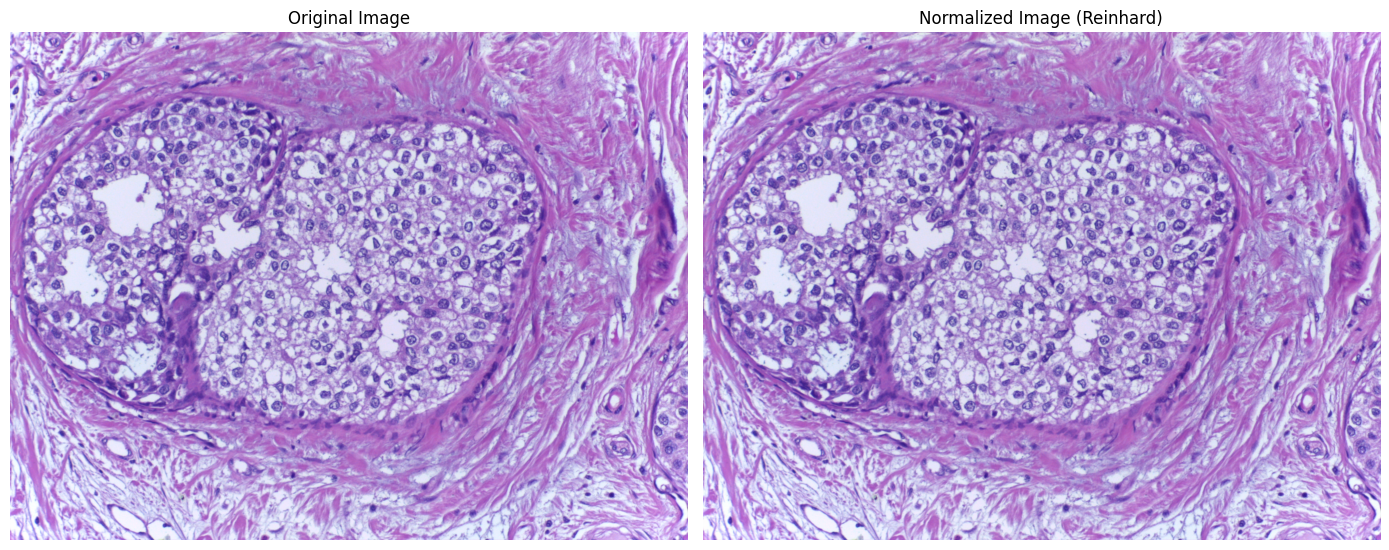

In [ ]:
# Calcolo delle statistiche target Lαβ per la normalizzazione di Reinhard.
# Verrà usata la prima immagine del dataset come riferimento per la normalizzazione.

# Carica l'immagine di riferimento
img_ref = Image.open(img_path)  # `img_path` è definito in precedenza
img_ref_np = np.array(img_ref) / 255.0  # Normalizza a 0-1 per skimage

# Converti in spazio colore Lαβ
lab_ref = color.rgb2lab(img_ref_np);

# Calcola la media e la deviazione standard per ogni canale L, α, β
global_target_mean_lab = np.array([np.mean(lab_ref[:, :, i]) for i in range(3)])
global_target_std_lab = np.array([np.std(lab_ref[:, :, i]) for i in range(3)])

print(f"Target Mean Lαβ: {global_target_mean_lab}")
print(f"Target Std Lαβ: {global_target_std_lab}")


def reinhard_color_normalize(img_np_rgb, target_mean_lab, target_std_lab):
    """
    Applica la normalizzazione del colore di Reinhard ad un'immagine RGB.

    Args:
        img_np_rgb (np.array): Immagine di input in formato numpy array (RGB, 0-255).
        target_mean_lab (np.array): Vettore (L, a, b) delle medie target.
        target_std_lab (np.array): Vettore (L, a, b) delle deviazioni standard target.

    Returns:
        np.array: Immagine normalizzata in formato numpy array (RGB, 0-255).
    """
    # Normalizza l'immagine a 0-1 e converti in Lαβ
    img_float = img_np_rgb / 255.0
    lab_source = color.rgb2lab(img_float)

    # Calcola media e deviazione standard del canale Lαβ dell'immagine sorgente
    mean_source_lab = np.array([np.mean(lab_source[:, :, i]) for i in range(3)])
    std_source_lab = np.array([np.std(lab_source[:, :, i]) for i in range(3)])

    # Applica la trasformazione lineare
    normalized_lab = ((lab_source - mean_source_lab) * (target_std_lab / std_source_lab)) + target_mean_lab

    # Converti nuovamente in RGB e clip i valori per essere nel range 0-255
    normalized_rgb = color.lab2rgb(normalized_lab)
    normalized_rgb = np.clip(normalized_rgb, 0, 1) * 255

    return normalized_rgb.astype(np.uint8)


# --- Esempio di applicazione e visualizzazione ---
print("\n--- Esempio di Normalizzazione Reinhard ---")

# Carica un'immagine per la dimostrazione (usiamo la stessa img_path)
original_img = Image.open(img_path)
original_img_np = np.array(original_img)

# Applica la normalizzazione
normalized_img_np = reinhard_color_normalize(original_img_np, global_target_mean_lab, global_target_std_lab)

# Visualizza l'immagine originale e quella normalizzata
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(original_img_np)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(normalized_img_np)
axes[1].set_title('Normalized Image (Reinhard)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

CLAHE


--- Esempio di applicazione di Reinhard e CLAHE + Istogrammi ---


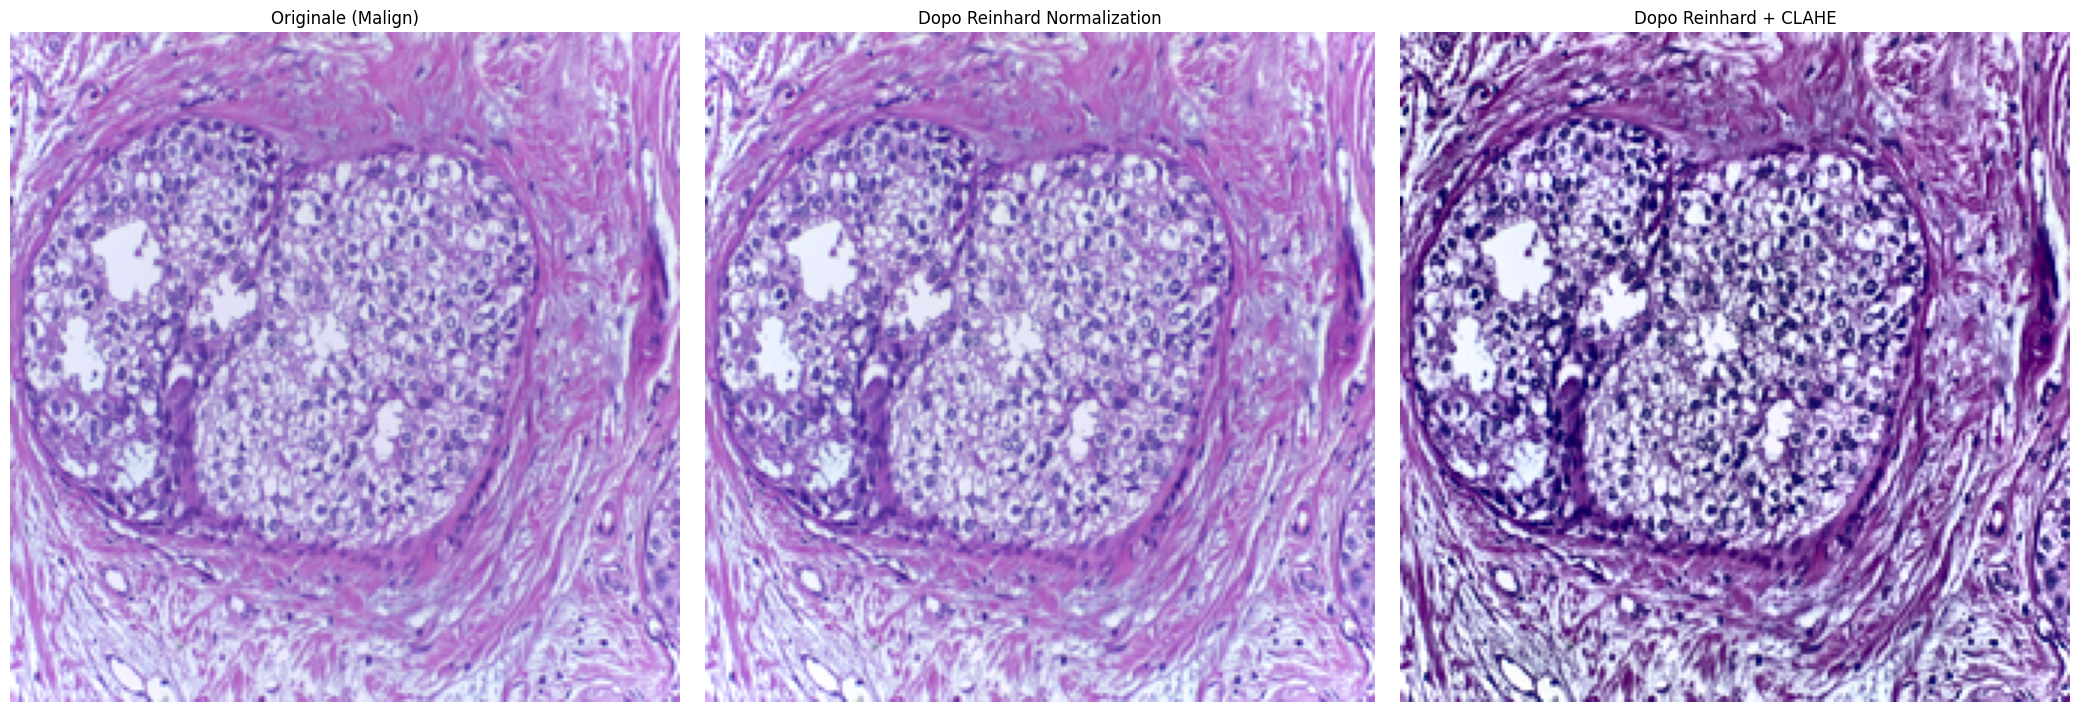

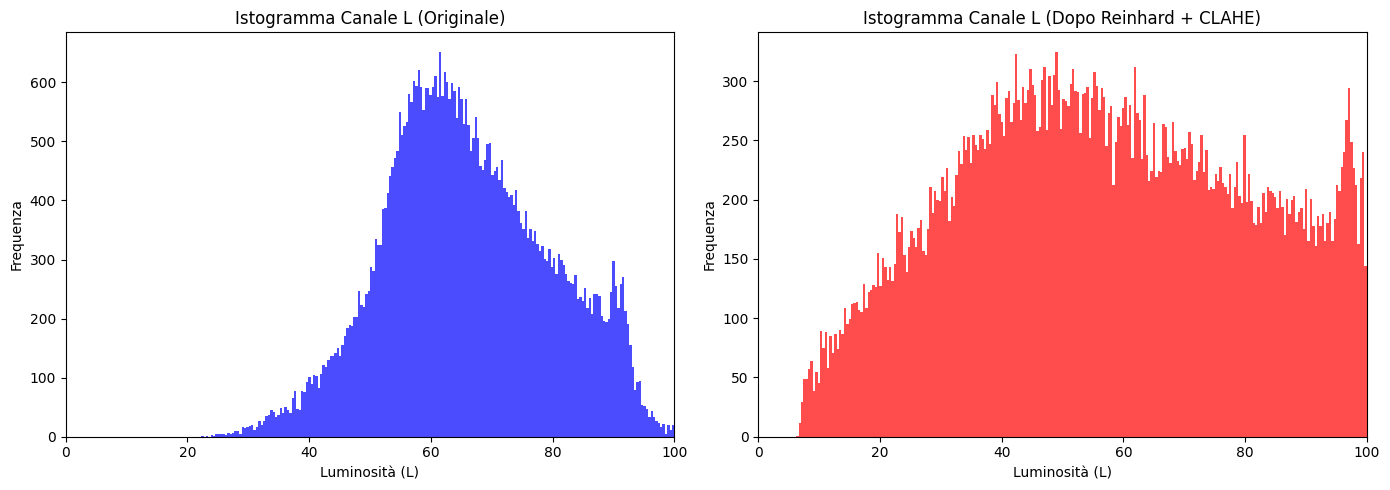

In [ ]:
# --- Funzione CLAHE ---
def apply_clahe(image_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Applica CLAHE (Contrast Limited Adaptive Histogram Equalization)
    sul canale di luminosità (L) in spazio LAB.

    Da usare DOPO la normalizzazione di Reinhard: si assume che
    'image_rgb' sia già stata color-normalizzata, così il CLAHE
    lavora su un'immagine con colorazione già omogenea, migliorando
    solo il contrasto locale senza interferire con la stima
    statistica (media/std) usata da Reinhard.

    Parameters
    ----------
    image_rgb : np.ndarray
        Immagine RGB (H, W, 3), dtype uint8.
    clip_limit : float
        Limita l'amplificazione del contrasto (evita over-enhancement
        e amplificazione del rumore).
    tile_grid_size : tuple
        Dimensione della griglia di tile su cui viene calcolato
        l'istogramma locale.

    Returns
    -------
    np.ndarray
        Immagine RGB con contrasto migliorato (stesso dtype/shape, uint8).
    """
    # Assumendo che image_rgb sia in formato RGB (come da PIL/matplotlib),
    # convertiamo in BGR per le funzioni LAB di OpenCV e poi in LAB.
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # CLAHE solo sul canale L
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel_eq = clahe.apply(l_channel)

    # Ricombina i canali e riconverti in RGB
    lab_eq = cv2.merge([l_channel_eq, a_channel, b_channel])
    image_clahe_bgr = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    image_clahe_rgb = cv2.cvtColor(image_clahe_bgr, cv2.COLOR_BGR2RGB)

    return image_clahe_rgb


# --- Esempio di applicazione e visualizzazione con istogrammi ---
print("\n--- Esempio di applicazione di Reinhard e CLAHE + Istogrammi ---")

sample_path = img_path
sample_label = "Malign"  # is002.tif appartiene a InSitu, mappato su Malign

# Carica l'immagine originale (e ridimensionala) per la visualizzazione e l'istogramma
original_img_pil = Image.open(sample_path).convert("RGB")
original_img_resized_np = np.array(original_img_pil.resize((IMG_SIZE, IMG_SIZE))).astype(np.uint8)

# Applica la normalizzazione di Reinhard
reinhard_img_np = reinhard_color_normalize(original_img_resized_np.astype(np.float32),
                                            global_target_mean_lab,
                                            global_target_std_lab)

# Applica CLAHE dopo la normalizzazione di Reinhard
reinhard_clahe_img_np = apply_clahe(reinhard_img_np)

# Plot delle immagini
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

axes[0].imshow(original_img_resized_np)
axes[0].set_title(f'Originale ({sample_label})')
axes[0].axis('off')

axes[1].imshow(reinhard_img_np)
axes[1].set_title('Dopo Reinhard Normalization')
axes[1].axis('off')

axes[2].imshow(reinhard_clahe_img_np)
axes[2].set_title('Dopo Reinhard + CLAHE')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Plot degli istogrammi del canale L
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(14, 5))

# Istogramma del canale L originale
original_lab = color.rgb2lab(original_img_resized_np)
original_l_channel = original_lab[:, :, 0]
axes_hist[0].hist(original_l_channel.flatten(), bins=256, range=(0, 100), color='blue', alpha=0.7)
axes_hist[0].set_title('Istogramma Canale L (Originale)')
axes_hist[0].set_xlabel('Luminosità (L)')
axes_hist[0].set_ylabel('Frequenza')
axes_hist[0].set_xlim([0, 100])

# Istogramma del canale L dopo Reinhard + CLAHE
reinhard_clahe_lab = color.rgb2lab(reinhard_clahe_img_np)
reinhard_clahe_l_channel = reinhard_clahe_lab[:, :, 0]
axes_hist[1].hist(reinhard_clahe_l_channel.flatten(), bins=256, range=(0, 100), color='red', alpha=0.7)
axes_hist[1].set_title('Istogramma Canale L (Dopo Reinhard + CLAHE)')
axes_hist[1].set_xlabel('Luminosità (L)')
axes_hist[1].set_ylabel('Frequenza')
axes_hist[1].set_xlim([0, 100])

plt.tight_layout()
plt.show()



---



## Split e preparazione dataset

Divisione dataset

In [ ]:
# il dataset df viene diviso in train dataset e uno temporaneo
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,                     # il 20% dei dati va in quello temporaneo
    stratify=df["label"],               # mantiene la proporzione delle etichette
    random_state=SEED                   # seme per il generatore di numeri casuali: la divisione del dataset resta la stessa
)

# divido quello temporaneo in validation e test set
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print(f"Number of Train sample is {len(train_df)}")
print(f"Number of Test sample is {len(test_df)}")
print(f"Number of Validation sample is {len(val_df)}")

Number of Train sample is 320
Number of Test sample is 40
Number of Validation sample is 40


Codifica numerica delle etichette

In [ ]:
train_df["label_id"] = train_df["label"].map(label_to_index).astype("int32")
val_df["label_id"] = val_df["label"].map(label_to_index).astype("int32")
test_df["label_id"] = test_df["label"].map(label_to_index).astype("int32")



---



## Pipeline tf.data

load_and_preprocess (Reinhard + CLAHE + augmentation) e make_dataset

In [ ]:
def preprocess_only(file_path, label, preprocess_fn):
    """
    Solo caricamento immagine + Reinhard + CLAHE.
    Il risultato è sempre identico per la stessa immagine: può essere cachato.
    """
    def _load_with_pil(path_tensor):
        path = path_tensor.numpy().decode("utf-8")
        img_pil = Image.open(path).convert("RGB")
        img_np_rgb = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE))).astype(np.uint8)

        reinhard_normalized_img_np = reinhard_color_normalize(img_np_rgb, global_target_mean_lab, global_target_std_lab)
        reinhard_clahe_img_np = apply_clahe(reinhard_normalized_img_np)

        return reinhard_clahe_img_np.astype(np.float32)

    img = tf.py_function(func=_load_with_pil, inp=[file_path], Tout=tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label


def augment_and_finalize(img, label, training=False, preprocess_fn=efficientnet_preprocess_input_fn):
    """
    Augmentation (solo in training) + preprocess_input specifico del backbone.
    Deve restare casuale ad ogni epoca: NON va messo prima di .cache().
    """
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))

    img = preprocess_fn(img)
    return img, label


def make_dataset(df, training=False, preprocess_fn=efficientnet_preprocess_input_fn):
    file_paths = df["file_path"].values
    labels = df["label_id"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)

    # Fase costosa (Reinhard + CLAHE): calcolata una sola volta grazie a .cache()
    ds = ds.map(lambda fp, lbl: preprocess_only(fp, lbl, preprocess_fn),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()

    # Fase leggera e casuale (augmentation + preprocess_input): rieseguita ad ogni epoca
    ds = ds.map(lambda img, lbl: augment_and_finalize(img, lbl, training=training, preprocess_fn=preprocess_fn),
                num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

Creazione di train_ds, val_ds, test_ds

In [ ]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)



---



## Modello EfficientNetB0

build_model

In [ ]:
def build_model(backbone_class=EfficientNetB0, fine_tune=False, fine_tune_fraction=0.20):
    base_model = backbone_class(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = fine_tune

    if fine_tune:
        total_layers = len(base_model.layers)
        # Calcola l'indice a partire dal quale sbloccare, in base alla percentuale
        fine_tune_at = int(total_layers * (1 - fine_tune_fraction))
        print(f"  {backbone_class.__name__}: {total_layers} layer totali, "
              f"sblocco dall'indice {fine_tune_at} in poi "
              f"({total_layers - fine_tune_at} layer, {fine_tune_fraction:.0%})")

        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=fine_tune)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu",
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model, base_model

In [ ]:
print("Numero totale di layer per ciascun backbone:")

efficientnet_backbone = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
resnet_backbone = ResNet50V2(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))

print(f"EfficientNetB0: {len(efficientnet_backbone.layers)} layers")
print(f"MobileNetV2:    {len(mobilenet_backbone.layers)} layers")
print(f"ResNet50V2:     {len(resnet_backbone.layers)} layers")

Numero totale di layer per ciascun backbone:
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
EfficientNetB0: 238 layers
MobileNetV2:    154 layers
ResNet50V2:     190 layers


Class weight (bilanciamento statistico + fattore correttivo clinico su Malign)

Si parte dal bilanciamento standard (`class_weight="balanced"`), che assegna pesi
inversamente proporzionali alla frequenza delle classi. Poiché nel dataset BACH le
immagini InSitu e Invasive vengono unite in un'unica classe Malign, questa risulta
la più numerosa e riceverebbe quindi il peso più basso — l'opposto di quanto
desiderabile in un contesto oncologico, dove un falso negativo su un tumore
maligno è clinicamente più grave di un falso positivo.

Per questo, il peso "statistico" di Malign viene moltiplicato per un fattore
correttivo (`MALIGN_BOOST_FACTOR`), per spingere il modello a privilegiare il
recall su questa classe.

In [ ]:
# Fattore moltiplicativo applicato al peso "statistico" della classe Malign,
# per riflettere il maggior costo clinico di un falso negativo su un tumore
# maligno. Un valore >1 aumenta la priorità di Malign; 1.0 equivale al solo
# bilanciamento statistico (nessuna correzione clinica).
MALIGN_BOOST_FACTOR = 1.5

# 1. Pesi statistici (bilanciamento per frequenza delle classi)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_df["label_id"].values
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights (solo bilanciamento statistico):", class_weight_dict)

# 2. Applica il fattore correttivo clinico solo sulla classe Malign
malign_id = label_to_index["Malign"]
class_weight_dict[malign_id] *= MALIGN_BOOST_FACTOR

print("Class weights (bilanciamento + priorità clinica su Malign):", class_weight_dict)

Class weights (solo bilanciamento statistico): {0: np.float64(1.3333333333333333), 1: np.float64(1.3333333333333333), 2: np.float64(0.6666666666666666)}
Class weights (bilanciamento + priorità clinica su Malign): {0: np.float64(1.3333333333333333), 1: np.float64(1.3333333333333333), 2: np.float64(1.0)}


Training Fase 1: feature extraction (backbone congelato)

In [ ]:
model, base_model = build_model(fine_tune=False)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_1 = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr_1 = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

print("=== Fase 1: feature extraction (backbone congelato) ===")
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop_1, reduce_lr_1],
    class_weight=class_weight_dict,
)

=== Fase 1: feature extraction (backbone congelato) ===
Epoch 1/15
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4153 - loss: 1.5546

/tmp/ipykernel_5573/4034018320.py:43: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  normalized_rgb = color.lab2rgb(normalized_lab)


8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5094 - loss: 1.3553 - val_accuracy: 0.6250 - val_loss: 0.8374 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6094 - loss: 1.1199 - val_accuracy: 0.6750 - val_loss: 0.7431 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6562 - loss: 0.9596 - val_accuracy: 0.7250 - val_loss: 0.6756 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7031 - loss: 0.8307 - val_accuracy: 0.7250 - val_loss: 0.6301 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7406 - loss: 0.8030 - val_accuracy: 0.7250 - val_loss: 0.6004 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7406 - loss: 0.8127 - val_accuracy: 0.7750 - val_loss: 0.5850 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7563 - loss: 0.7190 - val_accuracy: 0.7250 - val_loss: 

Training Fase 2: fine-tuning (BatchNorm congelati, LR più alto)

In [ ]:
base_model.trainable = True
total_layers = len(base_model.layers)
fine_tune_at = int(total_layers * (1 - FINE_TUNE_FRACTION))
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Tieni congelati i BatchNorm anche tra i layer sbloccati
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_2 = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr_2 = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

print("=== Fase 2: fine-tuning (ultimi layer del backbone scongelati) ===")
history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop_2, reduce_lr_2],
    class_weight=class_weight_dict,
)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")

=== Fase 2: fine-tuning (ultimi layer del backbone scongelati) ===
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7844 - loss: 0.6130 - val_accuracy: 0.7750 - val_loss: 0.5022 - learning_rate: 1.0000e-04
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8219 - loss: 0.5428 - val_accuracy: 0.7250 - val_loss: 0.4954 - learning_rate: 1.0000e-04
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8438 - loss: 0.4665 - val_accuracy: 0.8000 - val_loss: 0.5065 - learning_rate: 1.0000e-04
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8719 - loss: 0.4089 - val_accuracy: 0.7250 - val_loss: 0.4922 - learning_rate: 1.0000e-04
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8938 - loss: 0.3905 - val_accuracy: 0.7500 - val_loss: 0.4897 - learning_rate: 1.0000e-04
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9125 - loss: 0.3622 - val_accuracy: 0.7750 - val_loss: 0.4862 - learning_rate: 1.0000e-04
Epoch 7/20
8/8 ━

Grafico loss e accuracy per epoca

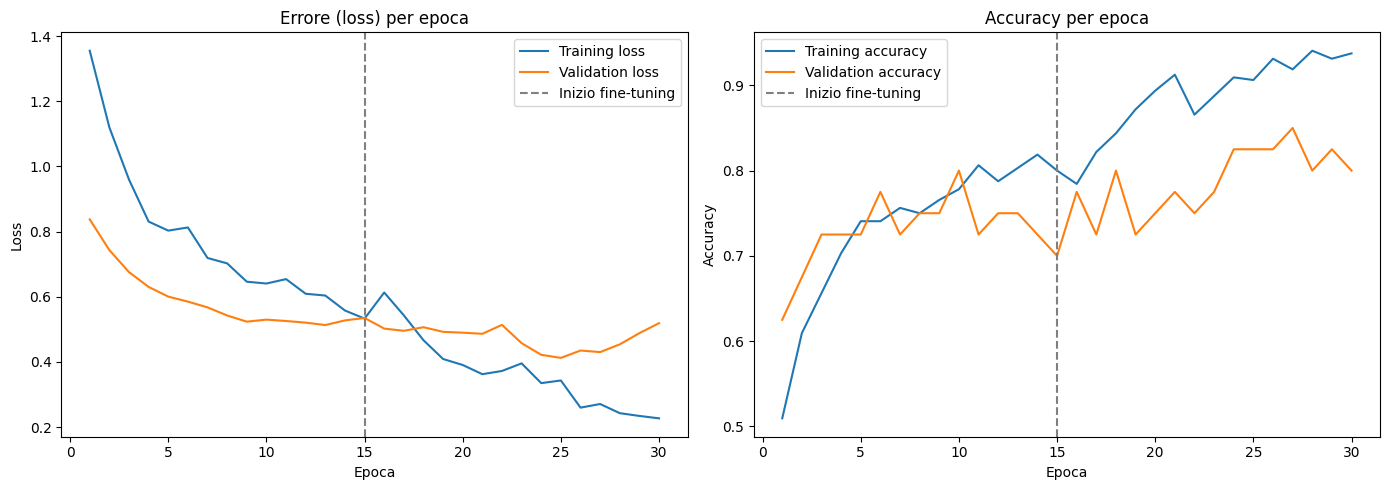

In [ ]:
train_loss = history_1.history["loss"] + history_2.history["loss"]
val_loss = history_1.history["val_loss"] + history_2.history["val_loss"]
train_acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]

epochs_range = range(1, len(train_loss) + 1)
fine_tune_start = len(history_1.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss, label="Training loss")
axes[0].plot(epochs_range, val_loss, label="Validation loss")
axes[0].axvline(x=fine_tune_start, color="gray", linestyle="--", label="Inizio fine-tuning")
axes[0].set_title("Errore (loss) per epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range, train_acc, label="Training accuracy")
axes[1].plot(epochs_range, val_acc, label="Validation accuracy")
axes[1].axvline(x=fine_tune_start, color="gray", linestyle="--", label="Inizio fine-tuning")
axes[1].set_title("Accuracy per epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Matrice di confusione e metriche

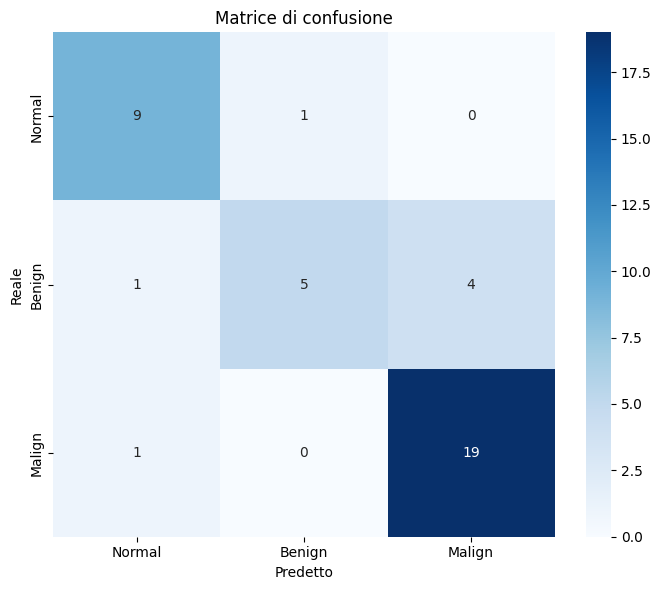

Accuracy complessiva: 0.8250

Classe         Precision      Recall    F1-score     Support
Normal            0.8182      0.9000      0.8571          10
Benign            0.8333      0.5000      0.6250          10
Malign            0.8261      0.9500      0.8837          20

--- Classification report completo ---
              precision    recall  f1-score   support

      Normal       0.82      0.90      0.86        10
      Benign       0.83      0.50      0.62        10
      Malign       0.83      0.95      0.88        20

    accuracy                           0.82        40
   macro avg       0.83      0.78      0.79        40
weighted avg       0.83      0.82      0.81        40



In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = [index_to_label[i] for i in range(NUM_CLASSES)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di confusione")
plt.tight_layout()
plt.show()

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(NUM_CLASSES))
)

print(f"Accuracy complessiva: {accuracy:.4f}\n")
print(f"{'Classe':<12}{'Precision':>12}{'Recall':>12}{'F1-score':>12}{'Support':>12}")
for i, cls in enumerate(class_names):
    print(f"{cls:<12}{precision[i]:>12.4f}{recall[i]:>12.4f}{f1[i]:>12.4f}{support[i]:>12d}")

print("\n--- Classification report completo ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Calcolo delle predizioni con TTA

In [ ]:
def tta_predict(model, image, n_augmentations=8, seed=None):
    """
    Genera n_augmentations versioni trasformate dell'immagine,
    fa la predizione su ciascuna, e restituisce la media delle probabilità.
    """
    predictions = []

    # Versione originale (sempre inclusa)
    predictions.append(model.predict(tf.expand_dims(image, axis=0), verbose=0)[0])

    for i in range(n_augmentations - 1):
        aug_image = image
        current_seed = seed + i if seed is not None else None

        # Le stesse trasformazioni usate in training, applicate ora in inferenza
        aug_image = tf.image.random_flip_left_right(aug_image, seed=current_seed)
        aug_image = tf.image.random_flip_up_down(aug_image, seed=current_seed)
        # Per rot90, tf.random.uniform ha bisogno del seed
        aug_image = tf.image.rot90(aug_image, k=tf.random.uniform([], 0, 4, dtype=tf.int32, seed=current_seed))

        pred = model.predict(tf.expand_dims(aug_image, axis=0), verbose=0)[0]
        predictions.append(pred)

    # Media delle probabilità su tutte le versioni
    avg_prediction = np.mean(predictions, axis=0)
    return avg_prediction

In [ ]:
y_true_tta = []
y_pred_tta = []

for images, labels in test_ds.unbatch():
    avg_pred = tta_predict(model, images, n_augmentations=8, seed=SEED)
    y_true_tta.append(labels.numpy())
    y_pred_tta.append(np.argmax(avg_pred))

y_true_tta = np.array(y_true_tta)
y_pred_tta = np.array(y_pred_tta)

print(f"Accuracy senza TTA: {accuracy_score(y_true, y_pred):.4f}")
print(f"Accuracy con TTA:   {accuracy_score(y_true_tta, y_pred_tta):.4f}")

Accuracy senza TTA: 0.8250
Accuracy con TTA:   0.8000


Matrice di confusione con TTA

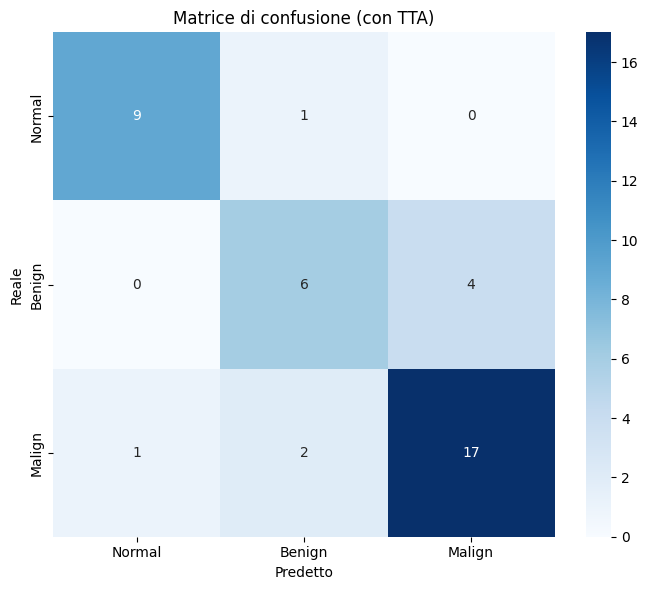

In [ ]:
cm_tta = confusion_matrix(y_true_tta, y_pred_tta)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_tta, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di confusione (con TTA)")
plt.tight_layout()
plt.show()



---



## MobileNetV2

Il build model precedente è generalizzato per poter esere usato anche in modelli differenti

MobileNetV2: dataset con preprocessing dedicato

In [ ]:
train_ds_mobilenet = make_dataset(train_df, training=True, preprocess_fn=mobilenet_preprocess_input_fn)
val_ds_mobilenet = make_dataset(val_df, training=False, preprocess_fn=mobilenet_preprocess_input_fn)
test_ds_mobilenet = make_dataset(test_df, training=False, preprocess_fn=mobilenet_preprocess_input_fn)

MobileNetV2 - Training Fase 1: feature extraction (backbone congelato)

In [ ]:
model_mobilenet, base_model_mobilenet = build_model(backbone_class=MobileNetV2, fine_tune=False)

model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_1_mobilenet = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr_1_mobilenet = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

print("=== MobileNetV2 Fase 1: feature extraction (backbone congelato) ===")
history_1_mobilenet = model_mobilenet.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=15,
    callbacks=[early_stop_1_mobilenet, reduce_lr_1_mobilenet],
    class_weight=class_weight_dict,
)

=== MobileNetV2 Fase 1: feature extraction (backbone congelato) ===
Epoch 1/15
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3741 - loss: 2.2762

/tmp/ipykernel_5573/4034018320.py:43: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  normalized_rgb = color.lab2rgb(normalized_lab)


8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.3969 - loss: 1.9518 - val_accuracy: 0.6500 - val_loss: 0.7913 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5250 - loss: 1.2556 - val_accuracy: 0.8250 - val_loss: 0.7061 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6250 - loss: 1.0744 - val_accuracy: 0.8250 - val_loss: 0.6733 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6094 - loss: 1.0515 - val_accuracy: 0.8000 - val_loss: 0.6326 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6594 - loss: 0.8980 - val_accuracy: 0.7750 - val_loss: 0.6337 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6625 - loss: 0.9013 - val_accuracy: 0.8000 - val_loss: 0.6241 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7281 - loss: 0.8029 - val_accuracy: 0.8000 - val_loss: 

MobileNetV2 - Training Fase 2: fine-tuning (BatchNorm congelati, LR più alto)

In [ ]:
base_model_mobilenet.trainable = True
total_layers_mobilenet = len(base_model_mobilenet.layers)
fine_tune_at = int(total_layers_mobilenet * (1 - FINE_TUNE_FRACTION))
print(f"MobileNetV2: {total_layers_mobilenet} layer totali, sblocco dall'indice {fine_tune_at} "
      f"({total_layers_mobilenet - fine_tune_at} layer, {FINE_TUNE_FRACTION:.0%})")
for layer in base_model_mobilenet.layers[:fine_tune_at]:
    layer.trainable = False

# Tieni congelati i BatchNorm anche tra i layer sbloccati
for layer in base_model_mobilenet.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_2_mobilenet = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr_2_mobilenet = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

print("=== MobileNetV2 Fase 2: fine-tuning (ultimi layer del backbone scongelati) ===")
history_2_mobilenet = model_mobilenet.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=20,
    callbacks=[early_stop_2_mobilenet, reduce_lr_2_mobilenet],
    class_weight=class_weight_dict,
)

test_loss_mobilenet, test_acc_mobilenet = model_mobilenet.evaluate(test_ds_mobilenet)
print(f"Test accuracy MobileNetV2: {test_acc_mobilenet:.4f}")

MobileNetV2: 154 layer totali, sblocco dall'indice 123 (31 layer, 20%)
=== MobileNetV2 Fase 2: fine-tuning (ultimi layer del backbone scongelati) ===
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 973ms/step - accuracy: 0.6687 - loss: 0.9796 - val_accuracy: 0.8000 - val_loss: 0.6180 - learning_rate: 1.0000e-04
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6844 - loss: 0.9231 - val_accuracy: 0.8500 - val_loss: 0.5479 - learning_rate: 1.0000e-04
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6531 - loss: 0.9195 - val_accuracy: 0.8500 - val_loss: 0.5522 - learning_rate: 1.0000e-04
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7063 - loss: 0.8582 - val_accuracy: 0.8250 - val_loss: 0.6046 - learning_rate: 1.0000e-04
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7312 - loss: 0.7922 - val_accuracy: 0.7000 - val_loss: 0.6207 - learning_rate: 1.0000e-04
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7531 - loss: 0.6758 

MobileNetV2 - Grafico loss e accuracy per epoca

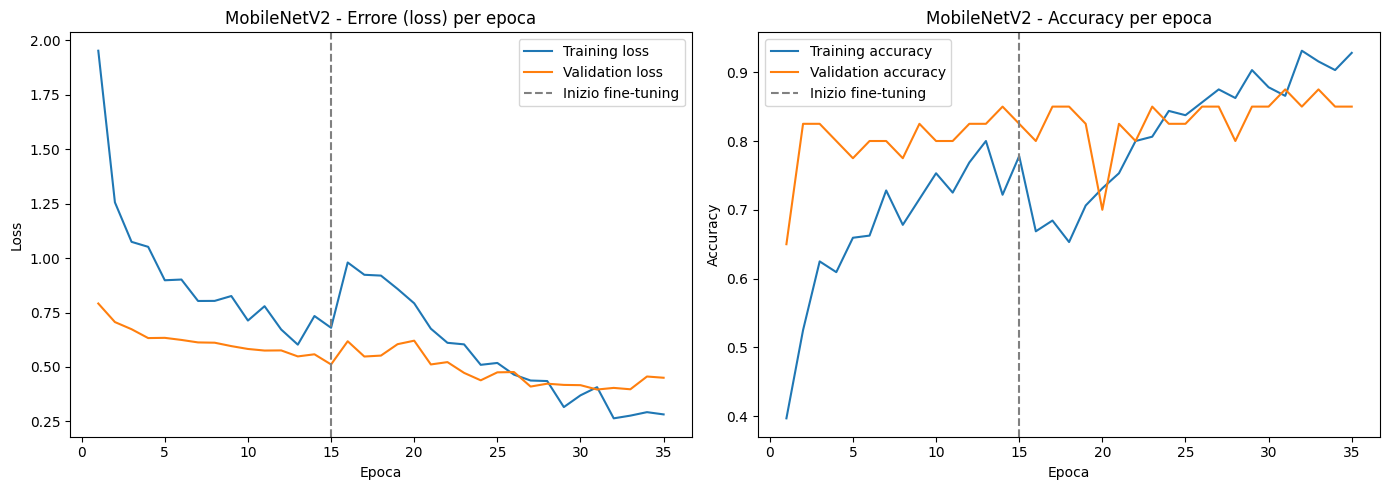

In [ ]:
train_loss_mobilenet = history_1_mobilenet.history["loss"] + history_2_mobilenet.history["loss"]
val_loss_mobilenet = history_1_mobilenet.history["val_loss"] + history_2_mobilenet.history["val_loss"]
train_acc_mobilenet = history_1_mobilenet.history["accuracy"] + history_2_mobilenet.history["accuracy"]
val_acc_mobilenet = history_1_mobilenet.history["val_accuracy"] + history_2_mobilenet.history["val_accuracy"]

epochs_range_mobilenet = range(1, len(train_loss_mobilenet) + 1)
fine_tune_start_mobilenet = len(history_1_mobilenet.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range_mobilenet, train_loss_mobilenet, label="Training loss")
axes[0].plot(epochs_range_mobilenet, val_loss_mobilenet, label="Validation loss")
axes[0].axvline(x=fine_tune_start_mobilenet, color="gray", linestyle="--", label="Inizio fine-tuning")
axes[0].set_title("MobileNetV2 - Errore (loss) per epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range_mobilenet, train_acc_mobilenet, label="Training accuracy")
axes[1].plot(epochs_range_mobilenet, val_acc_mobilenet, label="Validation accuracy")
axes[1].axvline(x=fine_tune_start_mobilenet, color="gray", linestyle="--", label="Inizio fine-tuning")
axes[1].set_title("MobileNetV2 - Accuracy per epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

MobileNetV2 - Matrice di confusione e metriche

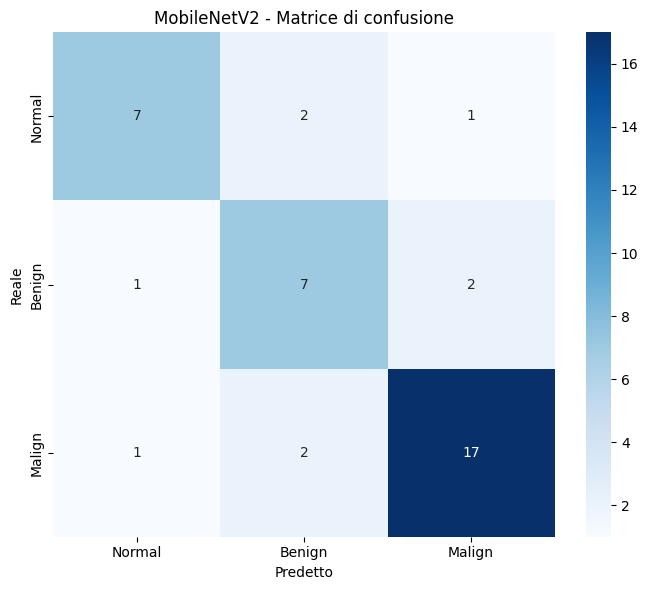

Accuracy complessiva MobileNetV2: 0.7750

Classe         Precision      Recall    F1-score     Support
Normal            0.7778      0.7000      0.7368          10
Benign            0.6364      0.7000      0.6667          10
Malign            0.8500      0.8500      0.8500          20


In [ ]:
y_true_mobilenet = []
y_pred_mobilenet = []

for images, labels in test_ds_mobilenet:
    preds = model_mobilenet.predict(images, verbose=0)
    y_true_mobilenet.extend(labels.numpy())
    y_pred_mobilenet.extend(np.argmax(preds, axis=1))

y_true_mobilenet = np.array(y_true_mobilenet)
y_pred_mobilenet = np.array(y_pred_mobilenet)

cm_mobilenet = confusion_matrix(y_true_mobilenet, y_pred_mobilenet)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_mobilenet, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("MobileNetV2 - Matrice di confusione")
plt.tight_layout()
plt.show()

accuracy_mobilenet = accuracy_score(y_true_mobilenet, y_pred_mobilenet)
precision_mobilenet, recall_mobilenet, f1_mobilenet, support_mobilenet = precision_recall_fscore_support(
    y_true_mobilenet, y_pred_mobilenet, labels=list(range(NUM_CLASSES))
)

print(f"Accuracy complessiva MobileNetV2: {accuracy_mobilenet:.4f}\n")
print(f"{'Classe':<12}{'Precision':>12}{'Recall':>12}{'F1-score':>12}{'Support':>12}")
for i, cls in enumerate(class_names):
    print(f"{cls:<12}{precision_mobilenet[i]:>12.4f}{recall_mobilenet[i]:>12.4f}{f1_mobilenet[i]:>12.4f}{support_mobilenet[i]:>12d}")

Calcolo delle predizioni con TTA

In [ ]:
y_true_tta_mobilenet = []
y_pred_tta_mobilenet = []

for images, labels in test_ds_mobilenet.unbatch():
    avg_pred = tta_predict(model_mobilenet, images, n_augmentations=8, seed=SEED)
    y_true_tta_mobilenet.append(labels.numpy())
    y_pred_tta_mobilenet.append(np.argmax(avg_pred))

y_true_tta_mobilenet = np.array(y_true_tta_mobilenet)
y_pred_tta_mobilenet = np.array(y_pred_tta_mobilenet)

print(f"Accuracy MobileNetV2 senza TTA: {accuracy_score(y_true_mobilenet, y_pred_mobilenet):.4f}")
print(f"Accuracy MobileNetV2 con TTA:   {accuracy_score(y_true_tta_mobilenet, y_pred_tta_mobilenet):.4f}")

Accuracy MobileNetV2 senza TTA: 0.7750
Accuracy MobileNetV2 con TTA:   0.8250


Matrice di confusione con TTA

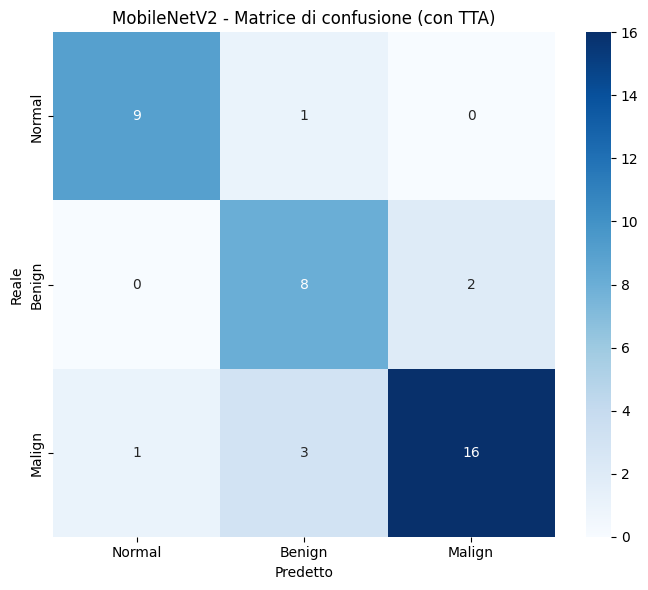

In [ ]:
cm_tta_mobilenet = confusion_matrix(y_true_tta_mobilenet, y_pred_tta_mobilenet)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_tta_mobilenet, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("MobileNetV2 - Matrice di confusione (con TTA)")
plt.tight_layout()
plt.show()



---



## ResNet50V2

ResNet50V2: dataset con preprocessing dedicato

In [ ]:
train_ds_resnet = make_dataset(train_df, training=True, preprocess_fn=resnet_preprocess_input_fn)
val_ds_resnet = make_dataset(val_df, training=False, preprocess_fn=resnet_preprocess_input_fn)
test_ds_resnet = make_dataset(test_df, training=False, preprocess_fn=resnet_preprocess_input_fn)

ResNet50V2 - Training Fase 1: feature extraction (backbone congelato)

In [ ]:
model_resnet, base_model_resnet = build_model(backbone_class=ResNet50V2, fine_tune=False)

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_1_resnet = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr_1_resnet = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

print("=== ResNet50V2 Fase 1: feature extraction (backbone congelato) ===")
history_1_resnet = model_resnet.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=15,
    callbacks=[early_stop_1_resnet, reduce_lr_1_resnet],
    class_weight=class_weight_dict,
)

=== ResNet50V2 Fase 1: feature extraction (backbone congelato) ===
Epoch 1/15
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3184 - loss: 2.2037

/tmp/ipykernel_5573/4034018320.py:43: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  normalized_rgb = color.lab2rgb(normalized_lab)


8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 835ms/step - accuracy: 0.3844 - loss: 1.9710 - val_accuracy: 0.7250 - val_loss: 0.7775 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5406 - loss: 1.3288 - val_accuracy: 0.7750 - val_loss: 0.6618 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6187 - loss: 0.9789 - val_accuracy: 0.6750 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6438 - loss: 1.0342 - val_accuracy: 0.7250 - val_loss: 0.6679 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6844 - loss: 0.8841 - val_accuracy: 0.7000 - val_loss: 0.6711 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.6406 - loss: 0.9130 - val_accuracy: 0.7750 - val_loss: 0.6574 - learning_rate: 5.0000e-04
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6938 - loss: 0.8437 - val_accuracy: 0.8000 - val

ResNet50V2 - Training Fase 2: fine-tuning (BatchNorm congelati, LR più alto)

In [ ]:
base_model_resnet.trainable = True
total_layers_resnet = len(base_model_resnet.layers)
fine_tune_at = int(total_layers_resnet * (1 - FINE_TUNE_FRACTION))
print(f"ResNet50V2: {total_layers_resnet} layer totali, sblocco dall'indice {fine_tune_at} "
      f"({total_layers_resnet - fine_tune_at} layer, {FINE_TUNE_FRACTION:.0%})")
for layer in base_model_resnet.layers[:fine_tune_at]:
    layer.trainable = False

# Tieni congelati i BatchNorm anche tra i layer sbloccati
for layer in base_model_resnet.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_2_resnet = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
reduce_lr_2_resnet = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6
)

print("=== ResNet50V2 Fase 2: fine-tuning (ultimi layer del backbone scongelati) ===")
history_2_resnet = model_resnet.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=20,
    callbacks=[early_stop_2_resnet, reduce_lr_2_resnet],
    class_weight=class_weight_dict,
)

test_loss_resnet, test_acc_resnet = model_resnet.evaluate(test_ds_resnet)
print(f"Test accuracy ResNet50V2: {test_acc_resnet:.4f}")

ResNet50V2: 190 layer totali, sblocco dall'indice 152 (38 layer, 20%)
=== ResNet50V2 Fase 2: fine-tuning (ultimi layer del backbone scongelati) ===
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 712ms/step - accuracy: 0.6594 - loss: 0.9350 - val_accuracy: 0.6750 - val_loss: 0.7584 - learning_rate: 1.0000e-04
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.7250 - loss: 0.7965 - val_accuracy: 0.8000 - val_loss: 0.5925 - learning_rate: 1.0000e-04
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8094 - loss: 0.6107 - val_accuracy: 0.9000 - val_loss: 0.5175 - learning_rate: 1.0000e-04
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8375 - loss: 0.4972 - val_accuracy: 0.7750 - val_loss: 0.6107 - learning_rate: 1.0000e-04
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8562 - loss: 0.4413 - val_accuracy: 0.8000 - val_loss: 0.8004 - learning_rate: 1.0000e-04
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8687 - loss: 0.4115 - 

ResNet50V2 - Grafico loss e accuracy per epoca

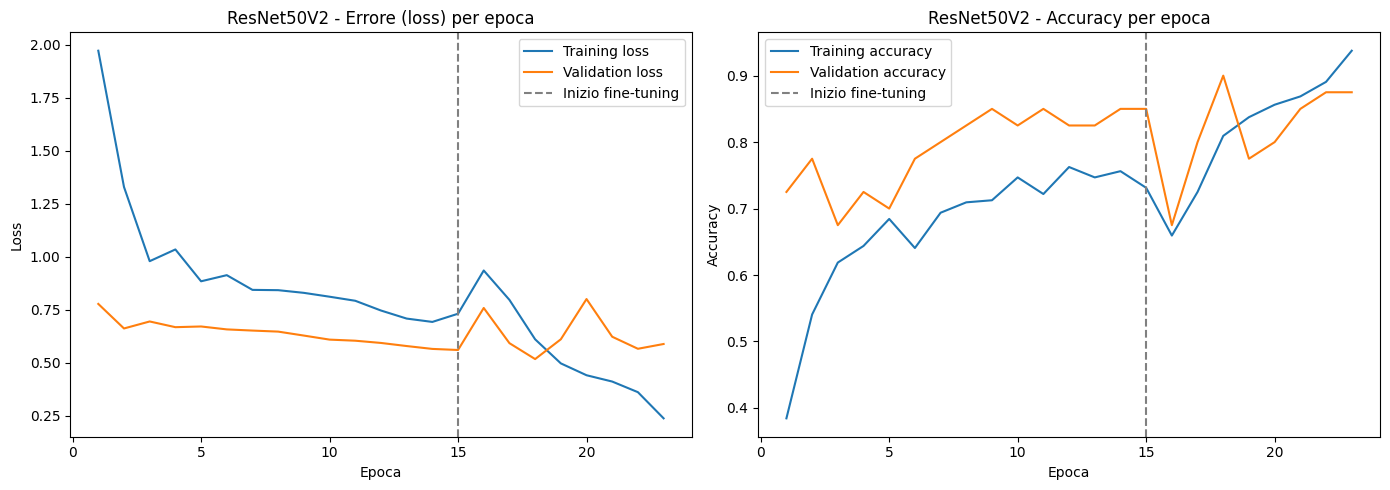

In [ ]:
train_loss_resnet = history_1_resnet.history["loss"] + history_2_resnet.history["loss"]
val_loss_resnet = history_1_resnet.history["val_loss"] + history_2_resnet.history["val_loss"]
train_acc_resnet = history_1_resnet.history["accuracy"] + history_2_resnet.history["accuracy"]
val_acc_resnet = history_1_resnet.history["val_accuracy"] + history_2_resnet.history["val_accuracy"]

epochs_range_resnet = range(1, len(train_loss_resnet) + 1)
fine_tune_start_resnet = len(history_1_resnet.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range_resnet, train_loss_resnet, label="Training loss")
axes[0].plot(epochs_range_resnet, val_loss_resnet, label="Validation loss")
axes[0].axvline(x=fine_tune_start_resnet, color="gray", linestyle="--", label="Inizio fine-tuning")
axes[0].set_title("ResNet50V2 - Errore (loss) per epoca")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs_range_resnet, train_acc_resnet, label="Training accuracy")
axes[1].plot(epochs_range_resnet, val_acc_resnet, label="Validation accuracy")
axes[1].axvline(x=fine_tune_start_resnet, color="gray", linestyle="--", label="Inizio fine-tuning")
axes[1].set_title("ResNet50V2 - Accuracy per epoca")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

ResNet50V2 - Matrice di confusione e metriche

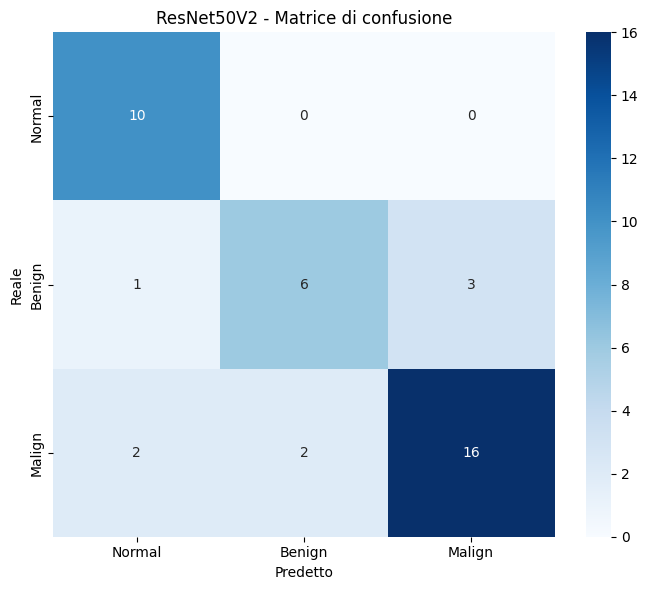

Accuracy complessiva ResNet50V2: 0.8000

Classe         Precision      Recall    F1-score     Support
Normal            0.7692      1.0000      0.8696          10
Benign            0.7500      0.6000      0.6667          10
Malign            0.8421      0.8000      0.8205          20


In [ ]:
y_true_resnet = []
y_pred_resnet = []

for images, labels in test_ds_resnet:
    preds = model_resnet.predict(images, verbose=0)
    y_true_resnet.extend(labels.numpy())
    y_pred_resnet.extend(np.argmax(preds, axis=1))

y_true_resnet = np.array(y_true_resnet)
y_pred_resnet = np.array(y_pred_resnet)

cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_resnet, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("ResNet50V2 - Matrice di confusione")
plt.tight_layout()
plt.show()

accuracy_resnet = accuracy_score(y_true_resnet, y_pred_resnet)
precision_resnet, recall_resnet, f1_resnet, support_resnet = precision_recall_fscore_support(
    y_true_resnet, y_pred_resnet, labels=list(range(NUM_CLASSES))
)

print(f"Accuracy complessiva ResNet50V2: {accuracy_resnet:.4f}\n")
print(f"{'Classe':<12}{'Precision':>12}{'Recall':>12}{'F1-score':>12}{'Support':>12}")
for i, cls in enumerate(class_names):
    print(f"{cls:<12}{precision_resnet[i]:>12.4f}{recall_resnet[i]:>12.4f}{f1_resnet[i]:>12.4f}{support_resnet[i]:>12d}")

Calcolo delle predizioni con TTA

In [ ]:
y_true_tta_resnet = []
y_pred_tta_resnet = []

for images, labels in test_ds_resnet.unbatch():
    avg_pred = tta_predict(model_resnet, images, n_augmentations=8, seed=SEED)
    y_true_tta_resnet.append(labels.numpy())
    y_pred_tta_resnet.append(np.argmax(avg_pred))

y_true_tta_resnet = np.array(y_true_tta_resnet)
y_pred_tta_resnet = np.array(y_pred_tta_resnet)

print(f"Accuracy ResNet50V2 senza TTA: {accuracy_score(y_true_resnet, y_pred_resnet):.4f}")
print(f"Accuracy ResNet50V2 con TTA:   {accuracy_score(y_true_tta_resnet, y_pred_tta_resnet):.4f}")

Accuracy ResNet50V2 senza TTA: 0.8000
Accuracy ResNet50V2 con TTA:   0.8500


Matrice di confusione con TTA

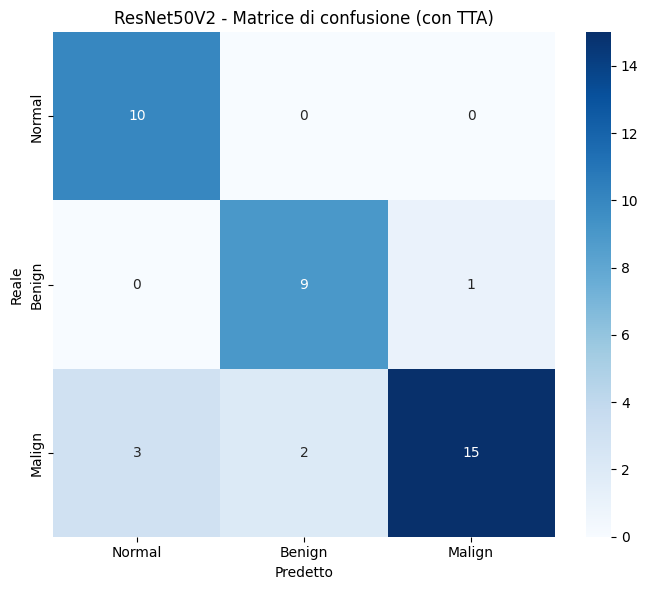

In [ ]:
cm_tta_resnet = confusion_matrix(y_true_tta_resnet, y_pred_tta_resnet)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_tta_resnet, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("ResNet50V2 - Matrice di confusione (con TTA)")
plt.tight_layout()
plt.show()



---



## Confronto tra modelli

Confronto tra i tre modelli: funzione di valutazione unica
(accuracy, F1 per classe/macro/weighted, ROC-AUC per classe, tempo di inferenza, numero di parametri)

In [ ]:
def evaluate_model_comparison(model, test_dataset, model_name, num_classes, class_names):
    y_true = []
    y_pred = []
    y_probs = []

    n_images = 0
    start_time = time.time()
    for images, labels in test_dataset:
        probs = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(probs, axis=1))
        y_probs.extend(probs)
        n_images += images.shape[0]
    elapsed = time.time() - start_time

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_classes))
    )
    f1_macro = f1.mean()
    f1_weighted = np.average(f1, weights=support)

    # ROC-AUC per classe, approccio One-vs-Rest
    y_true_bin = tf.keras.utils.to_categorical(y_true, num_classes=num_classes)
    roc_auc_per_class = {}
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc_per_class[class_names[i]] = auc(fpr, tpr)

    return {
        "model_name": model_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": accuracy,
        "f1_per_class": dict(zip(class_names, f1)),
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc_per_class": roc_auc_per_class,
        "n_params": model.count_params(),
        "inference_time_ms_per_image": (elapsed / n_images) * 1000,
    }


results_efficientnet = evaluate_model_comparison(model, test_ds, "EfficientNetB0", NUM_CLASSES, class_names)
results_resnet = evaluate_model_comparison(model_resnet, test_ds_resnet, "ResNet50V2", NUM_CLASSES, class_names)
results_mobilenet = evaluate_model_comparison(model_mobilenet, test_ds_mobilenet, "MobileNetV2", NUM_CLASSES, class_names)

all_results = [results_efficientnet, results_resnet, results_mobilenet]

1. Accuracy generale (indicativa: da leggere con cautela, essendo aggregata su classi sbilanciate)

In [ ]:
accuracy_df = pd.DataFrame({
    "Modello": [r["model_name"] for r in all_results],
    "Accuracy": [r["accuracy"] for r in all_results],
})
print(accuracy_df.round(4).to_string(index=False))
print("\nNota: l'accuracy generale può mascherare un basso recall sulle classi minoritarie")
print("(vedi F1 per classe e confusion matrix qui sotto per un quadro più affidabile).")

       Modello  Accuracy
EfficientNetB0     0.825
    ResNet50V2     0.800
   MobileNetV2     0.775

Nota: l'accuracy generale può mascherare un basso recall sulle classi minoritarie
(vedi F1 per classe e confusion matrix qui sotto per un quadro più affidabile).


2. F1-score per classe + F1 macro/weighted

In [ ]:
f1_rows = []
for r in all_results:
    row = {"Modello": r["model_name"], **r["f1_per_class"],
           "F1 macro": r["f1_macro"], "F1 weighted": r["f1_weighted"]}
    f1_rows.append(row)

f1_comparison_df = pd.DataFrame(f1_rows).set_index("Modello")
print(f1_comparison_df.round(4).to_string())

                Normal  Benign  Malign  F1 macro  F1 weighted
Modello                                                      
EfficientNetB0  0.8571  0.6250  0.8837    0.7886       0.8124
ResNet50V2      0.8696  0.6667  0.8205    0.7856       0.7943
MobileNetV2     0.7368  0.6667  0.8500    0.7512       0.7759


3. Confusion matrix (confronto affiancato)

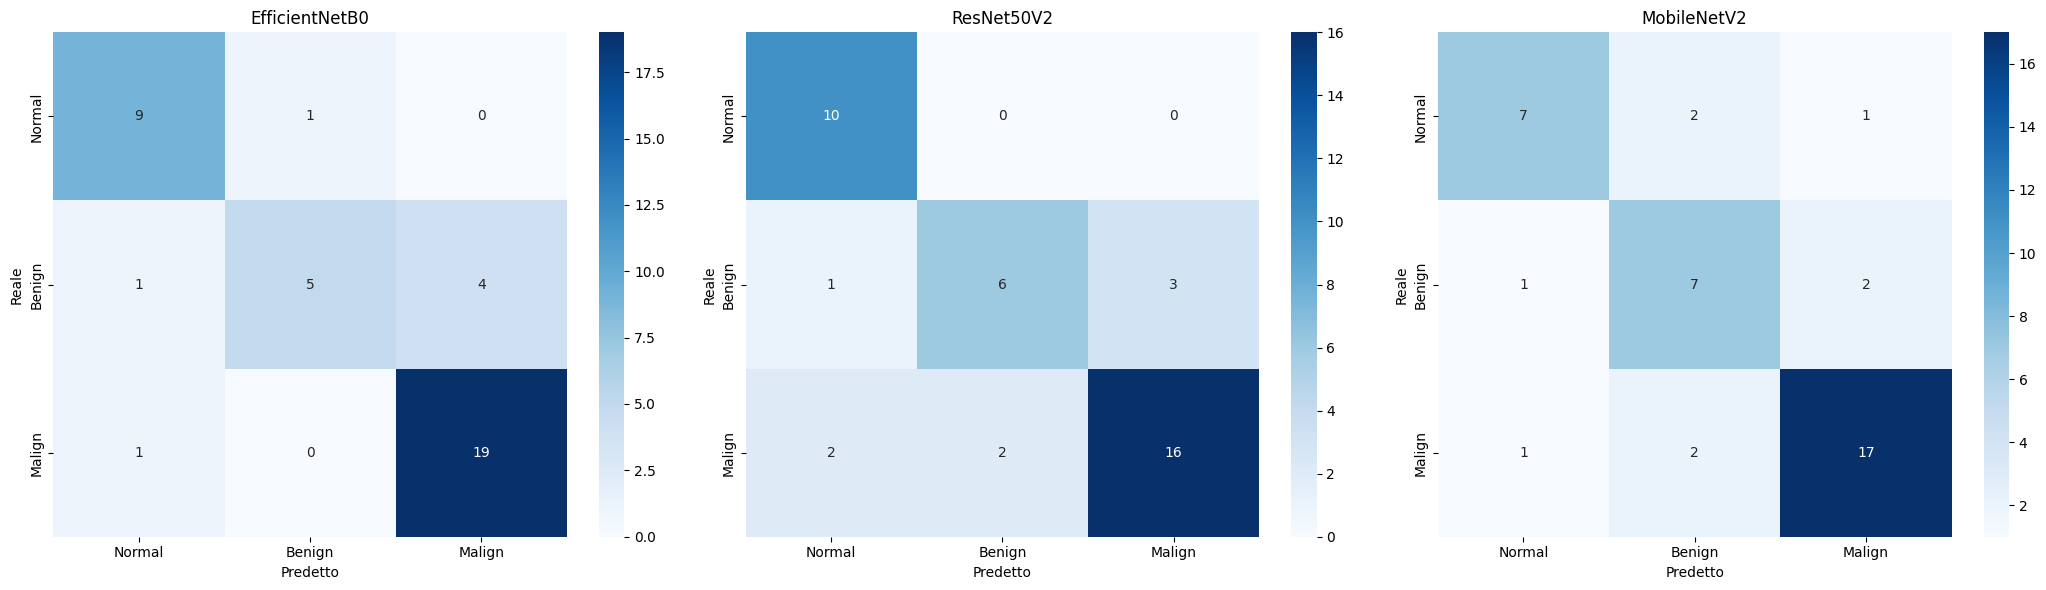

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, r in zip(axes, all_results):
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predetto")
    ax.set_ylabel("Reale")
    ax.set_title(r["model_name"])

plt.tight_layout()
plt.show()

4. ROC-AUC per classe

In [ ]:
auc_rows = []
for r in all_results:
    row = {"Modello": r["model_name"], **r["roc_auc_per_class"]}
    auc_rows.append(row)

auc_comparison_df = pd.DataFrame(auc_rows).set_index("Modello")
print(auc_comparison_df.round(4).to_string())

                Normal  Benign  Malign
Modello                               
EfficientNetB0  0.9667  0.9233  0.9175
ResNet50V2      0.9800  0.9100  0.8950
MobileNetV2     0.9700  0.8933  0.9225


5. Tempo di inferenza e numero di parametri

In [ ]:
efficiency_df = pd.DataFrame({
    "Modello": [r["model_name"] for r in all_results],
    "Parametri (milioni)": [r["n_params"] / 1e6 for r in all_results],
    "Tempo inferenza (ms/immagine)": [r["inference_time_ms_per_image"] for r in all_results],
})
print(efficiency_df.round(3).to_string(index=False))

       Modello  Parametri (milioni)  Tempo inferenza (ms/immagine)
EfficientNetB0                4.214                         27.013
    ResNet50V2               23.827                          3.585
   MobileNetV2                2.422                          3.187




---



## K-fold cross validation

K-fold Cross Validation (ResNet50V2)

Preparazione: label_id su tutto il dataset (non solo sugli split) + setup StratifiedKFold

In [ ]:
df["label_id"] = df["label"].map(label_to_index).astype("int32")

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

Funzione che allena e valuta un singolo fold (ResNet50V2)

In [ ]:
def train_and_evaluate_fold(train_df_fold, val_df_fold, fold_idx,
                             backbone_class=EfficientNetB0, preprocess_fn=efficientnet_preprocess_input_fn,
                             dev_size=0.1, fine_tune_fraction=0.20):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{N_FOLDS}  (train={len(train_df_fold)}, val={len(val_df_fold)})")
    print(f"{'='*60}")

    train_inner_df, dev_inner_df = train_test_split(
        train_df_fold,
        test_size=dev_size,
        stratify=train_df_fold["label"],
        random_state=SEED
    )
    print(f"  -> train_inner={len(train_inner_df)}, dev_inner={len(dev_inner_df)} (per early stopping)")

    train_ds_fold = make_dataset(train_inner_df, training=True, preprocess_fn=preprocess_fn)
    dev_ds_fold = make_dataset(dev_inner_df, training=False, preprocess_fn=preprocess_fn)
    val_ds_fold = make_dataset(val_df_fold, training=False, preprocess_fn=preprocess_fn)

    class_weights_fold = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1, 2]),
        y=train_df_fold["label_id"].values
    )
    class_weight_dict_fold = dict(enumerate(class_weights_fold))

    model_fold, base_model_fold = build_model(backbone_class=backbone_class, fine_tune=False)

    model_fold.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

    # Fase 1: feature extraction
    _ = model_fold.fit(
        train_ds_fold, validation_data=dev_ds_fold,
        epochs=15, callbacks=[early_stop, reduce_lr],
        class_weight=class_weight_dict_fold, verbose=0
    )

    # Fase 2: fine-tuning
    base_model.trainable = True
    total_layers = len(base_model.layers)
    fine_tune_at = int(total_layers * (1 - FINE_TUNE_FRACTION))
    for layer in base_model.layers[:fine_tune_at]:
          layer.trainable = False
    for layer in base_model_fold.layers[fine_tune_at:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model_fold.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stop_ft = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    reduce_lr_ft = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

    _ = model_fold.fit(
        train_ds_fold, validation_data=dev_ds_fold,
        epochs=20, callbacks=[early_stop_ft, reduce_lr_ft],
        class_weight=class_weight_dict_fold, verbose=0
    )

    # --- Valutazione finale su val_df_fold ---
    y_true_fold, y_pred_fold, y_pred_probs_fold = [], [], []
    for images, labels in val_ds_fold:
        preds = model_fold.predict(images, verbose=0)
        y_true_fold.extend(labels.numpy())
        y_pred_fold.extend(np.argmax(preds, axis=1))
        y_pred_probs_fold.extend(preds)

    y_true_fold = np.array(y_true_fold)
    y_pred_fold = np.array(y_pred_fold)
    y_pred_probs_fold = np.array(y_pred_probs_fold)

    acc = accuracy_score(y_true_fold, y_pred_fold)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_fold, y_pred_fold, labels=list(range(NUM_CLASSES)), zero_division=0
    )

    print(f"Fold {fold_idx + 1} — accuracy: {acc:.4f}")

    tf.keras.backend.clear_session()

    return {
        "fold": fold_idx + 1,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": y_true_fold,
        "y_pred": y_pred_fold,
        "y_pred_probs": y_pred_probs_fold
    }

Esecuzione k-fold cross validation (EfficientNetB0)

In [ ]:
fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(df, df["label_id"])):
    train_df_fold = df.iloc[train_idx].reset_index(drop=True)
    val_df_fold = df.iloc[val_idx].reset_index(drop=True)

    result = train_and_evaluate_fold(train_df_fold, val_df_fold, fold_idx)
    fold_results.append(result)


FOLD 1/5  (train=320, val=80)
  -> train_inner=288, dev_inner=32 (per early stopping)


/tmp/ipykernel_5573/4034018320.py:43: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  normalized_rgb = color.lab2rgb(normalized_lab)


Fold 1 — accuracy: 0.7500

FOLD 2/5  (train=320, val=80)
  -> train_inner=288, dev_inner=32 (per early stopping)


/tmp/ipykernel_5573/4034018320.py:43: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  normalized_rgb = color.lab2rgb(normalized_lab)


Fold 2 — accuracy: 0.8250

FOLD 3/5  (train=320, val=80)
  -> train_inner=288, dev_inner=32 (per early stopping)


...

Fold 3 — accuracy: 0.6875

FOLD 4/5  (train=320, val=80)
  -> train_inner=288, dev_inner=32 (per early stopping)


/tmp/ipykernel_5573/4034018320.py:43: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  normalized_rgb = color.lab2rgb(normalized_lab)


Fold 4 — accuracy: 0.7000

FOLD 5/5  (train=320, val=80)
  -> train_inner=288, dev_inner=32 (per early stopping)


/tmp/ipykernel_5573/4034018320.py:43: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  normalized_rgb = color.lab2rgb(normalized_lab)


Fold 5 — accuracy: 0.8000


Aggregazione dei risultati (media ± deviazione standard)

In [ ]:
accuracies = [r["accuracy"] for r in fold_results]

print(f"\n{'='*60}")
print("RISULTATI K-FOLD CROSS-VALIDATION (EfficientNetB0)")
print(f"{'='*60}")
print(f"Accuracy media: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Accuracy per fold: {[round(a, 4) for a in accuracies]}\n")

# Precision, recall, f1 medi per classe
precisions = np.array([r["precision"] for r in fold_results])
recalls = np.array([r["recall"] for r in fold_results])
f1s = np.array([r["f1"] for r in fold_results])

print(f"{'Classe':<12}{'Precision':>15}{'Recall':>15}{'F1-score':>15}")
for i, cls in enumerate(class_names):
    p_mean, p_std = precisions[:, i].mean(), precisions[:, i].std()
    r_mean, r_std = recalls[:, i].mean(), recalls[:, i].std()
    f_mean, f_std = f1s[:, i].mean(), f1s[:, i].std()
    print(f"{cls:<12}{p_mean:>8.4f}±{p_std:<6.4f}{r_mean:>8.4f}±{r_std:<6.4f}{f_mean:>8.4f}±{f_std:<6.4f}")


RISULTATI K-FOLD CROSS-VALIDATION (EfficientNetB0)
Accuracy media: 0.7525 ± 0.0539
Accuracy per fold: [0.75, 0.825, 0.6875, 0.7, 0.8]

Classe            Precision         Recall       F1-score
Normal        0.7628±0.0304  0.8700±0.1030  0.8105±0.0553
Benign        0.6260±0.1353  0.5700±0.0678  0.5885±0.0752
Malign        0.8232±0.0499  0.7850±0.0515  0.8029±0.0444


Matrice di confusione aggregata (somma su tutti i fold)

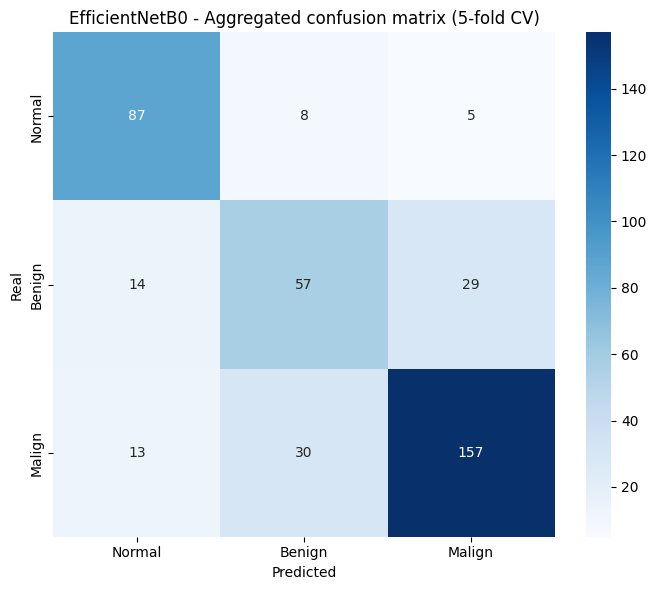

--- Classification report aggregato (k-fold, EfficientNetB0) ---
              precision    recall  f1-score   support

      Normal       0.76      0.87      0.81       100
      Benign       0.60      0.57      0.58       100
      Malign       0.82      0.79      0.80       200

    accuracy                           0.75       400
   macro avg       0.73      0.74      0.73       400
weighted avg       0.75      0.75      0.75       400



In [ ]:
y_true_all = np.concatenate([r["y_true"] for r in fold_results])
y_pred_all = np.concatenate([r["y_pred"] for r in fold_results])

cm_kfold = confusion_matrix(y_true_all, y_pred_all)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_kfold, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title(f"EfficientNetB0 - Aggregated confusion matrix ({N_FOLDS}-fold CV)")
plt.tight_layout()
plt.show()

print("--- Classification report aggregato (k-fold, EfficientNetB0) ---")
print(classification_report(y_true_all, y_pred_all, target_names=class_names))

Confronto diretto con lo split singolo precedente

In [ ]:
print(f"{'Metodo':<30}{'Accuracy':>12}")
print(f"{'Singolo split (test set) EfficientNetB0':<30}{test_acc:>12.4f}")
print(f"{'K-fold CV EfficientNetB0 (media)':<30}{np.mean(accuracies):>12.4f}")
print(f"{'K-fold CV EfficientNetB0 (aggregata)':<30}{accuracy_score(y_true_all, y_pred_all):>12.4f}")

print(f"\nDeviazione standard tra i fold: ±{np.std(accuracies):.4f}")
print("Una deviazione standard alta indica che le prestazioni sono sensibili a quale")
print("porzione di dati finisce in training/validazione — segnale di dataset piccolo.")

Metodo                            Accuracy
Singolo split (test set) EfficientNetB0      0.8250
K-fold CV EfficientNetB0 (media)      0.7525
K-fold CV EfficientNetB0 (aggregata)      0.7525

Deviazione standard tra i fold: ±0.0539
Una deviazione standard alta indica che le prestazioni sono sensibili a quale
porzione di dati finisce in training/validazione — segnale di dataset piccolo.


Curve ROC/AUC —(K-fold CV aggregato)

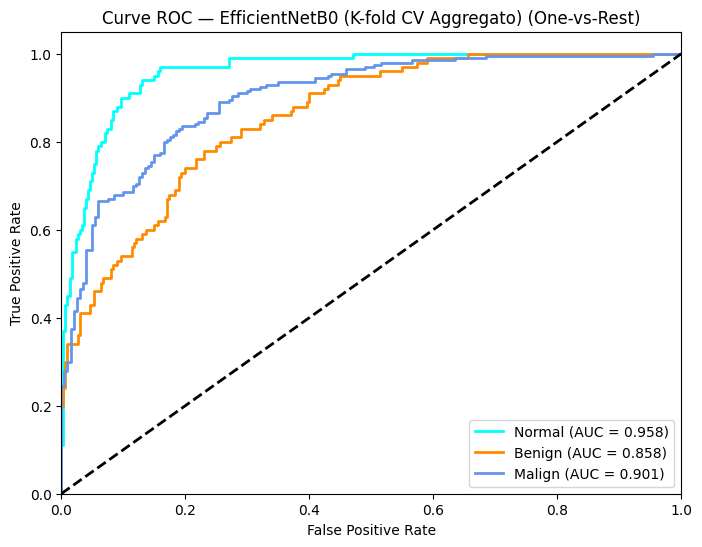

AUC per classe (EfficientNetB0, K-fold aggregato):
  Normal: 0.9584
  Benign: 0.8581
  Malign: 0.9011


In [ ]:
def plot_roc_curves(model, test_dataset, model_name, num_classes, class_names,
                     y_true_aggregated=None, y_pred_probs_aggregated=None):
    """
    Disegna le curve ROC One-vs-Rest per un modello.
    Se vengono forniti y_true_aggregated / y_pred_probs_aggregated (es. da k-fold),
    li usa direttamente invece di rifare le predizioni su model/test_dataset.
    """
    if y_true_aggregated is not None and y_pred_probs_aggregated is not None:
        y_true_roc = y_true_aggregated
        y_pred_probs_roc = y_pred_probs_aggregated
    else:
        y_true_roc = []
        y_pred_probs_roc = []
        for images, labels in test_dataset:
            probs = model.predict(images, verbose=0)
            y_true_roc.extend(labels.numpy())
            y_pred_probs_roc.extend(probs)
        y_true_roc = np.array(y_true_roc)
        y_pred_probs_roc = np.array(y_pred_probs_roc)

    y_true_bin = tf.keras.utils.to_categorical(y_true_roc, num_classes=num_classes)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs_roc[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

    for i, color in zip(range(num_classes), colors):
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Curve ROC — {model_name} (One-vs-Rest)')
    ax.legend(loc="lower right")
    return fig, ax, roc_auc


# Riusa y_true_all e y_pred_probs raccolti nel k-fold di EfficientNetB0
y_pred_probs_all_kfold = np.concatenate([r["y_pred_probs"] for r in fold_results])

fig_kfold, ax_kfold, aucs_resnet_kfold = plot_roc_curves(
    model=None,
    test_dataset=None,
    model_name="EfficientNetB0 (K-fold CV Aggregato)",
    num_classes=NUM_CLASSES,
    class_names=class_names,
    y_true_aggregated=y_true_all,
    y_pred_probs_aggregated=y_pred_probs_all_kfold,
)
plt.show()

print("AUC per classe (EfficientNetB0, K-fold aggregato):")
for cls, auc_val in aucs_resnet_kfold.items():
    print(f"  {class_names[cls]}: {auc_val:.4f}")



---



## Patch-based approch

setup e pulizia memoria

In [ ]:
import gc
from sklearn.model_selection import StratifiedGroupKFold

# Libera la memoria di eventuali modelli precedenti rimasti in sessione,
# prima di iniziare un esperimento più pesante in termini di RAM
tf.keras.backend.clear_session()
gc.collect()

PATCH_SIZE = 384
PATCH_STRIDE = 200
MAX_PATCHES_PER_IMAGE = 16

funzione di estrazione coordinate patch

In [ ]:
def get_patch_coordinates_patch(img_np, patch_size=PATCH_SIZE, stride=PATCH_STRIDE, background_thresh=0.85):
    """
    Ritorna una lista di coordinate (y, x) per patch valide, scartando
    quelle prevalentemente bianche (sfondo del vetrino).
    """
    h, w = img_np.shape[:2]
    coords = []

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            patch = img_np[y:y+patch_size, x:x+patch_size]
            gray = patch.mean(axis=-1)
            frac_white = np.mean(gray > 220)
            if frac_white < background_thresh:
                coords.append((y, x))

    return coords

costruzione del dataframe di patch a partire dagli split esistenti

In [ ]:
def build_patch_dataframe_patch(df_source, patch_size=PATCH_SIZE, stride=PATCH_STRIDE,
                                 max_patches_per_image=MAX_PATCHES_PER_IMAGE):
    """
    Espande un dataframe whole-image (con colonne file_path, label, label_id)
    in un dataframe a livello di patch, con una colonna image_id per poter
    riaggregare le predizioni dopo.
    """
    records = []

    for image_id, row in df_source.reset_index(drop=True).iterrows():
        img_pil = Image.open(row["file_path"]).convert("RGB")
        img_np = np.array(img_pil)

        coords = get_patch_coordinates_patch(img_np, patch_size=patch_size, stride=stride)

        if len(coords) > max_patches_per_image:
            rng = np.random.RandomState(SEED + image_id)
            idx = rng.choice(len(coords), size=max_patches_per_image, replace=False)
            coords = [coords[i] for i in idx]

        for (y, x) in coords:
            records.append({
                "file_path": row["file_path"],
                "label": row["label"],
                "label_id": row["label_id"],
                "image_id": image_id,
                "patch_y": y,
                "patch_x": x,
            })

    return pd.DataFrame(records)

applica la funzione ai tre split già esistenti

In [ ]:
print("Costruzione patch dataframe (può richiedere qualche minuto)...")

train_patch_df = build_patch_dataframe_patch(train_df)
val_patch_df = build_patch_dataframe_patch(val_df)
test_patch_df = build_patch_dataframe_patch(test_df)

print(f"\nImmagini originali  -> train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print(f"Patch generate       -> train={len(train_patch_df)}, val={len(val_patch_df)}, test={len(test_patch_df)}")
print("\nDistribuzione classi nelle patch di training:")
print(train_patch_df["label"].value_counts())

Costruzione patch dataframe (può richiedere qualche minuto)...

Immagini originali  -> train=320, val=40, test=40
Patch generate       -> train=5120, val=640, test=640

Distribuzione classi nelle patch di training:
label
Malign    2560
Normal    1280
Benign    1280
Name: count, dtype: int64


sanity check visivo: alcune patch a confronto con l'immagine originale

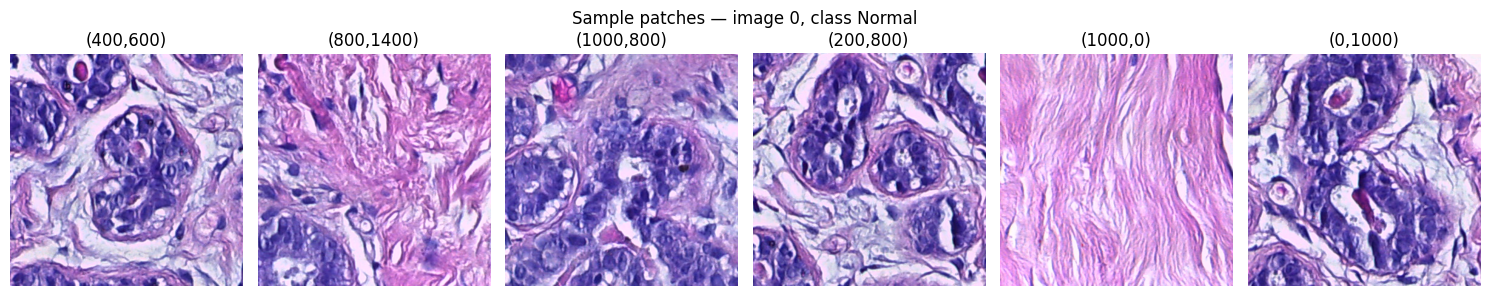

In [ ]:
sample_image_id = train_patch_df["image_id"].iloc[0]
sample_patches = train_patch_df[train_patch_df["image_id"] == sample_image_id].head(6)

fig, axes = plt.subplots(1, len(sample_patches), figsize=(15, 3))
img_pil = Image.open(sample_patches.iloc[0]["file_path"]).convert("RGB")
img_np = np.array(img_pil)

for ax, (_, r) in zip(axes, sample_patches.iterrows()):
    patch = img_np[r["patch_y"]:r["patch_y"]+PATCH_SIZE, r["patch_x"]:r["patch_x"]+PATCH_SIZE]
    ax.imshow(patch)
    ax.set_title(f"({r['patch_y']},{r['patch_x']})")
    ax.axis("off")

plt.suptitle(f"Sample patches — image {sample_image_id}, class {sample_patches.iloc[0]['label']}")
plt.tight_layout()
plt.show()

preprocessing e tf.data.Dataset per patch

In [ ]:
def preprocess_only_patch(file_path, patch_y, patch_x, label, preprocess_fn, patch_size=PATCH_SIZE):
    def _load_patch_with_pil(path_tensor, y_tensor, x_tensor):
        path = path_tensor.numpy().decode("utf-8")
        y = int(y_tensor.numpy())
        x = int(x_tensor.numpy())

        img_pil = Image.open(path).convert("RGB")
        img_np_rgb = np.array(img_pil)
        patch = img_np_rgb[y:y+patch_size, x:x+patch_size].astype(np.uint8)

        reinhard_normalized = reinhard_color_normalize(patch, global_target_mean_lab, global_target_std_lab)
        reinhard_clahe = apply_clahe(reinhard_normalized)

        return reinhard_clahe.astype(np.float32)

    img = tf.py_function(func=_load_patch_with_pil, inp=[file_path, patch_y, patch_x], Tout=tf.float32)
    img.set_shape([patch_size, patch_size, 3])
    return img, label


def make_patch_dataset(patch_df, training=False, preprocess_fn=efficientnet_preprocess_input_fn, cache_path=None):
    file_paths = patch_df["file_path"].values
    patch_ys = patch_df["patch_y"].values.astype("int32")
    patch_xs = patch_df["patch_x"].values.astype("int32")
    labels = patch_df["label_id"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((file_paths, patch_ys, patch_xs, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(patch_df), seed=SEED)

    ds = ds.map(lambda fp, y, x, lbl: preprocess_only_patch(fp, y, x, lbl, preprocess_fn),
                num_parallel_calls=tf.data.AUTOTUNE)

    # Cache su disco invece che in RAM: con migliaia di patch la cache
    # in memoria può diventare pesante (vedi nota su Colab/Kaggle)
    if cache_path:
        # Clear cache directory if it exists for debugging/re-training
        if tf.io.gfile.exists(cache_path):
            tf.io.gfile.rmtree(cache_path)
        ds = ds.cache(cache_path)
    else:
        ds = ds.cache()


    ds = ds.map(lambda img, lbl: augment_and_finalize(img, lbl, training=training, preprocess_fn=preprocess_fn),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

creazione dei dataset

In [ ]:
train_ds_patch = make_patch_dataset(train_patch_df, training=True,
                                     preprocess_fn=efficientnet_preprocess_input_fn,
                                     cache_path="/tmp/patch_cache_train")
val_ds_patch = make_patch_dataset(val_patch_df, training=False,
                                   preprocess_fn=efficientnet_preprocess_input_fn,
                                   cache_path="/tmp/patch_cache_val")
test_ds_patch = make_patch_dataset(test_patch_df, training=False,
                                    preprocess_fn=efficientnet_preprocess_input_fn,
                                    cache_path="/tmp/patch_cache_test")

class weight sulle patch di training

In [ ]:
class_weights_patch = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_patch_df["label_id"].values
)
class_weight_dict_patch = dict(enumerate(class_weights_patch))
print(class_weight_dict_patch)

{0: np.float64(1.3333333333333333), 1: np.float64(1.3333333333333333), 2: np.float64(0.6666666666666666)}


costruzione e training del modello (riusa build_model, Fase 1)

In [ ]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Conversion from CIE-LAB.*",
    category=UserWarning,
)

In [ ]:
# Salva il valore corrente di IMG_SIZE
original_img_size_for_patch = IMG_SIZE
# Imposta IMG_SIZE su PATCH_SIZE per la costruzione del modello patch
IMG_SIZE = PATCH_SIZE

model_patch, base_model_patch = build_model(backbone_class=EfficientNetB0, fine_tune=False)

# Ripristina il valore originale di IMG_SIZE
IMG_SIZE = original_img_size_for_patch

model_patch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_patch = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr_patch = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history_1_patch = model_patch.fit(
    train_ds_patch,
    validation_data=val_ds_patch,
    epochs=15,
    callbacks=[early_stop_patch, reduce_lr_patch],
    class_weight=class_weight_dict_patch,
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.6201 - loss: 0.8700 - val_accuracy: 0.6812 - val_loss: 0.7667 - learning_rate: 0.0010
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.7008 - loss: 0.7143 - val_accuracy: 0.7312 - val_loss: 0.6906 - learning_rate: 0.0010
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.7350 - loss: 0.6599 - val_accuracy: 0.7453 - val_loss: 0.6684 - learning_rate: 0.0010
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.7523 - loss: 0.6252 - val_accuracy: 0.7641 - val_loss: 0.6583 - learning_rate: 0.0010
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.7652 - loss: 0.6051 - val_accuracy: 0.7641 - val_loss: 0.6147 - learning_rate: 0.0010
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.7746 - loss: 0.5848 - val_accuracy: 0.7469 - val_loss: 0.6247 - learning_rate: 0.0010
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.7793 - lo

Fase 2: fine-tuning

In [ ]:
base_model_patch.trainable = True
total_layers_patch = len(base_model_patch.layers)
fine_tune_at_patch = int(total_layers_patch * (1 - FINE_TUNE_FRACTION))
for layer in base_model_patch.layers[:fine_tune_at_patch]:
    layer.trainable = False
for layer in base_model_patch.layers[fine_tune_at_patch:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_patch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop_ft_patch = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr_ft_patch = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history_2_patch = model_patch.fit(
    train_ds_patch,
    validation_data=val_ds_patch,
    epochs=20,
    callbacks=[early_stop_ft_patch, reduce_lr_ft_patch],
    class_weight=class_weight_dict_patch,
)

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.8309 - loss: 0.4768 - val_accuracy: 0.7734 - val_loss: 0.6055 - learning_rate: 1.0000e-04
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.8463 - loss: 0.4147 - val_accuracy: 0.8031 - val_loss: 0.5633 - learning_rate: 1.0000e-04
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.8729 - loss: 0.3681 - val_accuracy: 0.7859 - val_loss: 0.5736 - learning_rate: 1.0000e-04
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.8879 - loss: 0.3392 - val_accuracy: 0.7812 - val_loss: 0.5911 - learning_rate: 1.0000e-04
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.8934 - loss: 0.3115 - val_accuracy: 0.7828 - val_loss: 0.5728 - learning_rate: 1.0000e-04
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.9158 - loss: 0.2684 - val_accuracy: 0.8031 - val_loss: 0.5529 - learning_rate: 5.0000e-05
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/st

Grafico accuracy/metriche

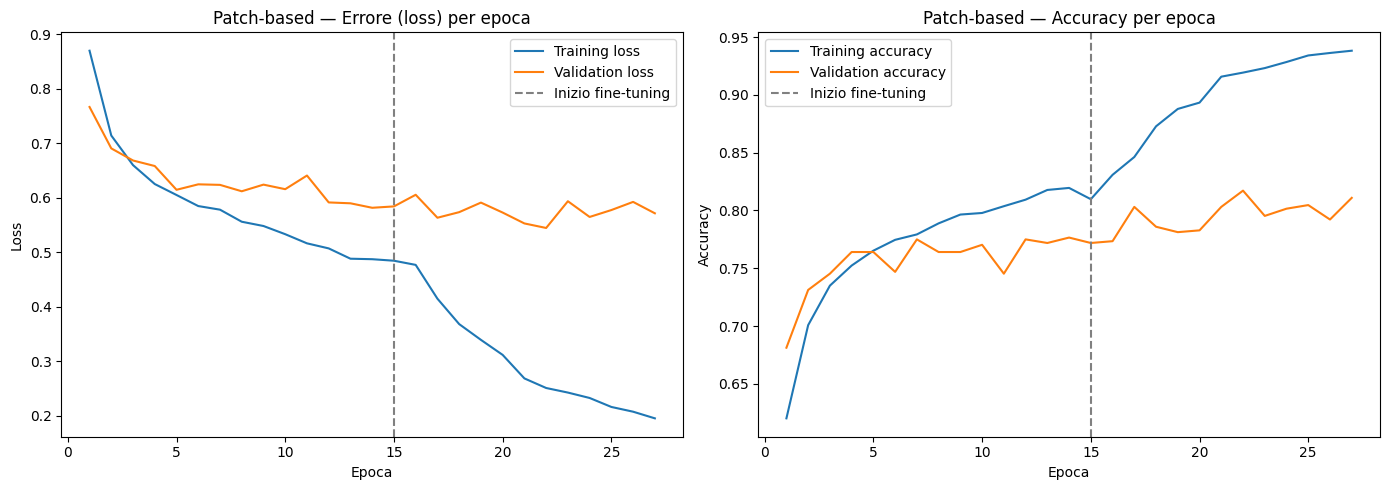

In [ ]:
fine_tune_start_patch = len(history_1_patch.history["loss"])
loss_patch = history_1_patch.history["loss"] + history_2_patch.history["loss"]
val_loss_patch = history_1_patch.history["val_loss"] + history_2_patch.history["val_loss"]
acc_patch = history_1_patch.history["accuracy"] + history_2_patch.history["accuracy"]
val_acc_patch = history_1_patch.history["val_accuracy"] + history_2_patch.history["val_accuracy"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(loss_patch)+1), loss_patch, label="Training loss")
axes[0].plot(range(1, len(val_loss_patch)+1), val_loss_patch, label="Validation loss")
axes[0].axvline(x=fine_tune_start_patch, color="gray", linestyle="--", label="Inizio fine-tuning")
axes[0].set_title("Patch-based — Errore (loss) per epoca")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Loss"); axes[0].legend()

axes[1].plot(range(1, len(acc_patch)+1), acc_patch, label="Training accuracy")
axes[1].plot(range(1, len(val_acc_patch)+1), val_acc_patch, label="Validation accuracy")
axes[1].axvline(x=fine_tune_start_patch, color="gray", linestyle="--", label="Inizio fine-tuning")
axes[1].set_title("Patch-based — Accuracy per epoca")
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.show()

funzione di aggregazione patch → immagine

In [ ]:
def predict_and_aggregate_by_image_vote(model, patch_ds, patch_df_ordered):
    all_probs = []
    for images, labels in patch_ds:
        preds = model.predict(images, verbose=0)
        all_probs.extend(preds)

    patch_df_result = patch_df_ordered.copy()
    patch_df_result["probs"] = list(all_probs)
    patch_df_result["pred_patch"] = patch_df_result["probs"].apply(np.argmax)

    image_level = patch_df_result.groupby("image_id").agg(
        label_id=("label_id", "first"),
        pred_id=("pred_patch", lambda s: np.bincount(s, minlength=NUM_CLASSES).argmax())
    ).reset_index()

    return image_level

valutazione finale a livello di immagine, sul test set

In [ ]:
image_level_results = predict_and_aggregate_by_image_vote(model_patch, test_ds_patch, test_patch_df)

y_true_patch = image_level_results["label_id"].values
y_pred_patch = image_level_results["pred_id"].values

accuracy_patch = accuracy_score(y_true_patch, y_pred_patch)
precision_patch, recall_patch, f1_patch, support_patch = precision_recall_fscore_support(
    y_true_patch, y_pred_patch, labels=list(range(NUM_CLASSES)), zero_division=0
)

print(f"Accuracy (patch-based, aggregata a livello di immagine): {accuracy_patch:.4f}")
print(f"\nConfronto: EfficientNetB0 whole-image singolo split = 0.8250")

class_names = ["Normal", "Benign", "Malign"]
for i, name in enumerate(class_names):
    print(f"{name:<10} precision={precision_patch[i]:.3f}  recall={recall_patch[i]:.3f}  f1={f1_patch[i]:.3f}")

Accuracy (patch-based, aggregata a livello di immagine): 0.9250

Confronto: EfficientNetB0 whole-image singolo split = 0.8250
Normal     precision=1.000  recall=0.800  f1=0.889
Benign     precision=0.769  recall=1.000  f1=0.870
Malign     precision=1.000  recall=0.950  f1=0.974


matrice di confusione a livello di immagine

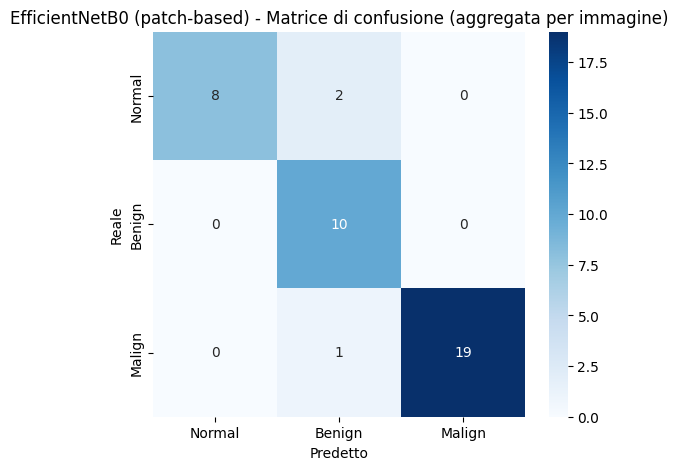

In [ ]:
cm_patch = confusion_matrix(y_true_patch, y_pred_patch)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_patch, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predetto"); plt.ylabel("Reale")
plt.title("EfficientNetB0 (patch-based) - Matrice di confusione (aggregata per immagine)")
plt.show()

In [ ]:
y_true_raw, y_pred_raw = [], []
for images, labels in test_ds_patch:
    preds = model_patch.predict(images, verbose=0)
    y_true_raw.extend(labels.numpy())
    y_pred_raw.extend(np.argmax(preds, axis=1))

print("Accuracy a livello di singola patch:", accuracy_score(y_true_raw, y_pred_raw))
print(classification_report(y_true_raw, y_pred_raw, target_names=class_names))

Accuracy a livello di singola patch: 0.8625
              precision    recall  f1-score   support

      Normal       0.84      0.74      0.79       160
      Benign       0.75      0.84      0.80       160
      Malign       0.93      0.93      0.93       320

    accuracy                           0.86       640
   macro avg       0.84      0.84      0.84       640
weighted avg       0.87      0.86      0.86       640





---



## K-fold cross validation con patch

costruzione del patch dataframe sull'intero dataset

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

# Ensure 'label_id' is present in df before building the patch dataframe
df["label_id"] = df["label"].map(label_to_index).astype("int32")

print("Costruzione patch dataframe sull'intero dataset (può richiedere qualche minuto)...")
full_patch_df = build_patch_dataframe_patch(df, patch_size=PATCH_SIZE, stride=PATCH_STRIDE,
                                             max_patches_per_image=MAX_PATCHES_PER_IMAGE)

print(f"Immagini totali: {len(df)}  ->  patch totali: {len(full_patch_df)}")
print(full_patch_df["label"].value_counts())

Costruzione patch dataframe sull'intero dataset (può richiedere qualche minuto)...
Immagini totali: 400  ->  patch totali: 6400
label
Malign    3200
Benign    1600
Normal    1600
Name: count, dtype: int64


split train/dev interno a livello di immagine

In [ ]:
def split_patch_train_dev(patch_df_fold, dev_size=0.1, seed=SEED):
    """
    Divide un patch dataframe di un fold in train_inner/dev_inner,
    garantendo che tutte le patch della stessa immagine restino insieme
    (split fatto sugli image_id, non sulle singole patch).
    """
    images_unique = patch_df_fold.drop_duplicates("image_id")[["image_id", "label_id"]]

    train_img_ids, dev_img_ids = train_test_split(
        images_unique["image_id"],
        test_size=dev_size,
        stratify=images_unique["label_id"],
        random_state=seed
    )

    train_inner_df = patch_df_fold[patch_df_fold["image_id"].isin(train_img_ids)].reset_index(drop=True)
    dev_inner_df = patch_df_fold[patch_df_fold["image_id"].isin(dev_img_ids)].reset_index(drop=True)

    return train_inner_df, dev_inner_df

Funzione di aggregazione riusata

In [ ]:
def predict_patches_raw_fold(model, patch_ds, patch_df_ordered):
    all_probs = []
    for images, labels in patch_ds:
        preds = model.predict(images, verbose=0)
        all_probs.extend(preds)

    patch_df_result = patch_df_ordered.copy()
    patch_df_result["probs"] = list(all_probs)
    return patch_df_result


def aggregate_median_fold(patch_df_result):
    image_level = patch_df_result.groupby("image_id").agg(
        label_id=("label_id", "first"),
        agg_probs=("probs", lambda s: np.median(np.stack(s), axis=0))
    ).reset_index()
    image_level["pred_id"] = image_level["agg_probs"].apply(np.argmax)
    return image_level

funzione principale: allena e valuta un singolo fold patch-based

In [ ]:
def train_and_evaluate_fold_patch(train_patch_df_fold, val_patch_df_fold, fold_idx,
                                   backbone_class=EfficientNetB0,
                                   preprocess_fn=efficientnet_preprocess_input_fn,
                                   dev_size=0.1, fine_tune_fraction=FINE_TUNE_FRACTION):
    n_images_train = train_patch_df_fold["image_id"].nunique()
    n_images_val = val_patch_df_fold["image_id"].nunique()
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{N_FOLDS} (patch-based)")
    print(f"  train: {n_images_train} immagini / {len(train_patch_df_fold)} patch")
    print(f"  val:   {n_images_val} immagini / {len(val_patch_df_fold)} patch")
    print(f"{'='*60}")

    # Split interno train/dev, a livello di immagine
    train_inner_df, dev_inner_df = split_patch_train_dev(train_patch_df_fold, dev_size=dev_size, seed=SEED)
    print(f"  -> train_inner={train_inner_df['image_id'].nunique()} immagini, "
          f"dev_inner={dev_inner_df['image_id'].nunique()} immagini (per early stopping)")

    train_ds_fold = make_patch_dataset(train_inner_df, training=True, preprocess_fn=preprocess_fn)
    dev_ds_fold = make_patch_dataset(dev_inner_df, training=False, preprocess_fn=preprocess_fn)
    val_ds_fold = make_patch_dataset(val_patch_df_fold, training=False, preprocess_fn=preprocess_fn)

    class_weights_fold = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1, 2]),
        y=train_inner_df["label_id"].values
    )
    class_weight_dict_fold = dict(enumerate(class_weights_fold))

    # Applica il fattore correttivo clinico solo sulla classe Malign, se definito
    if 'MALIGN_BOOST_FACTOR' in globals() and MALIGN_BOOST_FACTOR > 1:
        malign_id = label_to_index["Malign"]
        class_weight_dict_fold[malign_id] *= MALIGN_BOOST_FACTOR
        print(f"  -> Pesi classi con boost Malign: {class_weight_dict_fold}")
    else:
        print(f"  -> Pesi classi (solo bilanciamento): {class_weight_dict_fold}")


    model_fold, base_model_fold = build_model(backbone_class=backbone_class, fine_tune=False)

    model_fold.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

    # Fase 1
    _ = model_fold.fit(
        train_ds_fold, validation_data=dev_ds_fold,
        epochs=15, callbacks=[early_stop, reduce_lr],
        class_weight=class_weight_dict_fold, verbose=0
    )

    # Fase 2: fine-tuning, stessa FINE_TUNE_FRACTION usata altrove
    base_model_fold.trainable = True
    total_layers_fold = len(base_model_fold.layers)
    fine_tune_at = int(total_layers_fold * (1 - fine_tune_fraction))
    for layer in base_model_fold.layers[:fine_tune_at]:
        layer.trainable = False
    for layer in base_model_fold.layers[fine_tune_at:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model_fold.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stop_ft = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    reduce_lr_ft = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

    _ = model_fold.fit(
        train_ds_fold, validation_data=dev_ds_fold,
        epochs=20, callbacks=[early_stop_ft, reduce_lr_ft],
        class_weight=class_weight_dict_fold, verbose=0
    )

    # --- Valutazione: predizione per patch, poi aggregazione a livello di immagine ---
    patch_result_fold = predict_patches_raw_fold(model_fold, val_ds_fold, val_patch_df_fold)
    image_level_fold = aggregate_median_fold(patch_result_fold)

    y_true_fold = image_level_fold["label_id"].values
    y_pred_fold = image_level_fold["pred_id"].values
    y_pred_probs_fold = np.stack(image_level_fold["agg_probs"].values)

    acc = accuracy_score(y_true_fold, y_pred_fold)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_fold, y_pred_fold, labels=list(range(NUM_CLASSES)), zero_division=0
    )

    print(f"Fold {fold_idx + 1} — accuracy (a livello di immagine, aggregata): {acc:.4f}")

    tf.keras.backend.clear_session()
    gc.collect()

    return {
        "fold": fold_idx + 1,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": y_true_fold,
        "y_pred": y_pred_fold,
        "y_pred_probs": y_pred_probs_fold
    }

esecuzione della k-fold

In [ ]:
sgkf_patch = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Salva il valore originale di IMG_SIZE prima del ciclo K-fold per le patch
original_img_size_for_kfold_patch = IMG_SIZE
# Imposta IMG_SIZE su PATCH_SIZE in modo che build_model utilizzi la dimensione corretta
IMG_SIZE = PATCH_SIZE

fold_results_patch = []

for fold_idx, (train_idx, val_idx) in enumerate(
        sgkf_patch.split(full_patch_df, full_patch_df["label_id"], groups=full_patch_df["image_id"])):

    train_patch_df_fold = full_patch_df.iloc[train_idx].reset_index(drop=True)
    val_patch_df_fold = full_patch_df.iloc[val_idx].reset_index(drop=True)

    result = train_and_evaluate_fold_patch(
        train_patch_df_fold, val_patch_df_fold, fold_idx,
        backbone_class=EfficientNetB0,
        preprocess_fn=efficientnet_preprocess_input_fn,
        fine_tune_fraction=FINE_TUNE_FRACTION
    )
    fold_results_patch.append(result)

# Ripristina il valore originale di IMG_SIZE dopo il ciclo K-fold per le patch
IMG_SIZE = original_img_size_for_kfold_patch


FOLD 1/5 (patch-based)
  train: 320 immagini / 5120 patch
  val:   80 immagini / 1280 patch
  -> train_inner=288 immagini, dev_inner=32 immagini (per early stopping)
  -> Pesi classi con boost Malign: {0: np.float64(1.3333333333333333), 1: np.float64(1.3333333333333333), 2: np.float64(1.0)}
Fold 1 — accuracy (a livello di immagine, aggregata): 0.8625

FOLD 2/5 (patch-based)
  train: 320 immagini / 5120 patch
  val:   80 immagini / 1280 patch
  -> train_inner=288 immagini, dev_inner=32 immagini (per early stopping)
  -> Pesi classi con boost Malign: {0: np.float64(1.352112676056338), 1: np.float64(1.3150684931506849), 2: np.float64(1.0)}
Fold 2 — accuracy (a livello di immagine, aggregata): 0.9125

FOLD 3/5 (patch-based)
  train: 320 immagini / 5120 patch
  val:   80 immagini / 1280 patch
  -> train_inner=288 immagini, dev_inner=32 immagini (per early stopping)
  -> Pesi classi con boost Malign: {0: np.float64(1.3150684931506849), 1: np.float64(1.3333333333333333), 2: np.float64(1.0069

Verifica di sicurezza

In [ ]:
for fold_idx, (train_idx, val_idx) in enumerate(
        sgkf_patch.split(full_patch_df, full_patch_df["label_id"], groups=full_patch_df["image_id"])):
    train_images = set(full_patch_df.iloc[train_idx]["image_id"])
    val_images = set(full_patch_df.iloc[val_idx]["image_id"])
    overlap = train_images & val_images
    assert len(overlap) == 0, f"Leakage nel fold {fold_idx}: {len(overlap)} immagini in comune!"
print("Nessun leakage tra train e val in nessun fold — controllo superato.")

Nessun leakage tra train e val in nessun fold — controllo superato.


aggregazione dei risultati sui 5 fold

In [ ]:
accuracies_patch = [r["accuracy"] for r in fold_results_patch]
print(f"Accuracy media: {np.mean(accuracies_patch):.4f} ± {np.std(accuracies_patch):.4f}")
print(f"Accuracy per fold: {[round(a, 4) for a in accuracies_patch]}")

precisions_patch = np.array([r["precision"] for r in fold_results_patch])
recalls_patch = np.array([r["recall"] for r in fold_results_patch])
f1s_patch = np.array([r["f1"] for r in fold_results_patch])

print("\nClasse            Precision         Recall       F1-score")
for i, name in enumerate(class_names):
    print(f"{name:<15} {precisions_patch[:, i].mean():.4f}±{precisions_patch[:, i].std():.4f}  "
          f"{recalls_patch[:, i].mean():.4f}±{recalls_patch[:, i].std():.4f}  "
          f"{f1s_patch[:, i].mean():.4f}±{f1s_patch[:, i].std():.4f}")

Accuracy media: 0.8900 ± 0.0200
Accuracy per fold: [0.8625, 0.9125, 0.9125, 0.875, 0.8875]

Classe            Precision         Recall       F1-score
Normal          0.8412±0.0767  0.8883±0.0603  0.8604±0.0424
Benign          0.8547±0.0911  0.8108±0.0550  0.8276±0.0396
Malign          0.9444±0.0185  0.9297±0.0198  0.9369±0.0148


matrice di confusione aggregata su tutti i fold

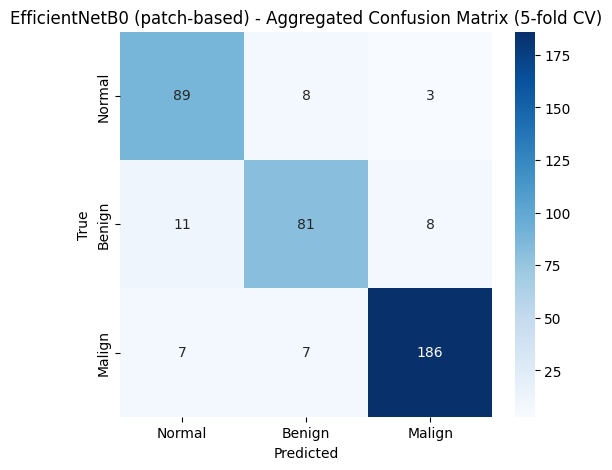


Aggregated Accuracy: 0.8900
              precision    recall  f1-score   support

      Normal       0.83      0.89      0.86       100
      Benign       0.84      0.81      0.83       100
      Malign       0.94      0.93      0.94       200

    accuracy                           0.89       400
   macro avg       0.87      0.88      0.87       400
weighted avg       0.89      0.89      0.89       400



In [ ]:
y_true_all_patch = np.concatenate([r["y_true"] for r in fold_results_patch])
y_pred_all_patch = np.concatenate([r["y_pred"] for r in fold_results_patch])

cm_patch_agg = confusion_matrix(y_true_all_patch, y_pred_all_patch)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_patch_agg, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("EfficientNetB0 (patch-based) - Aggregated Confusion Matrix (5-fold CV)")
plt.show()

print(f"\nAggregated Accuracy: {accuracy_score(y_true_all_patch, y_pred_all_patch):.4f}")
print(classification_report(y_true_all_patch, y_pred_all_patch, target_names=class_names))

curve ROC aggregate

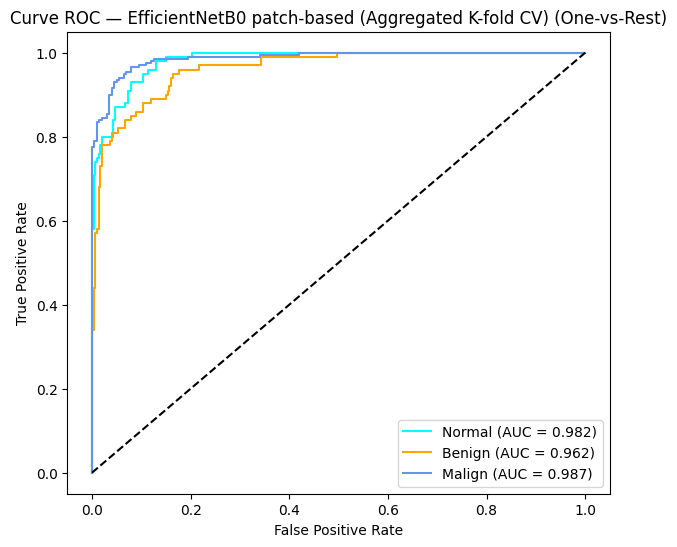

In [ ]:
y_pred_probs_all_patch = np.concatenate([r["y_pred_probs"] for r in fold_results_patch], axis=0)
y_true_bin_patch = label_binarize(y_true_all_patch, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(7, 6))
colors = ["cyan", "orange", "cornflowerblue"]
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin_patch[:, i], y_pred_probs_all_patch[:, i])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curve ROC — EfficientNetB0 patch-based (Aggregated K-fold CV) (One-vs-Rest)")
plt.legend()
plt.show()

tabella riassuntiva di confronto finale

In [ ]:
comparison_df = pd.DataFrame({
    "Metodo": [
        "Whole-image — K-fold CV (media)",
        "Patch-based — K-fold CV (media)",
        "Patch-based — K-fold CV (aggregata)"
    ],
    "Accuracy": [
        0.7825,  # valore già ottenuto in precedenza con whole-image
        np.mean(accuracies_patch),
        accuracy_score(y_true_all_patch, y_pred_all_patch)
    ]
})
print(comparison_df)

                                Metodo  Accuracy
0      Whole-image — K-fold CV (media)    0.7825
1      Patch-based — K-fold CV (media)    0.8900
2  Patch-based — K-fold CV (aggregata)    0.8900
